In [1]:
import os
for f in os.walk('/kaggle/input'):
    print(f)

('/kaggle/input', ['datasets'], [])
('/kaggle/input/datasets', ['ylmazcanekmek'], [])
('/kaggle/input/datasets/ylmazcanekmek', ['btc-thesis-final-datasets'], [])
('/kaggle/input/datasets/ylmazcanekmek/btc-thesis-final-datasets', [], ['mcgarch_wfv.csv', 'mcgarch_metadata.csv', 'mcgarch_forecasts.csv', 'BTCUSD_5min_2015_2025.csv'])


## 0 — IMPORTS & GLOBAL CONFIGURATION

In [2]:
import os, warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from scipy.stats import (jarque_bera, skew, kurtosis, norm as _norm, f as f_dist, t as t_dist)
from scipy.stats import pearsonr, spearmanr
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Reproducibility 

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
# Kaggle paths 

CSV_PATH = "/kaggle/input/datasets/ylmazcanekmek/btc-thesis-final-datasets/BTCUSD_5min_2015_2025.csv"
MCGARCH_DIR = "/kaggle/input/datasets/ylmazcanekmek/btc-thesis-final-datasets"

In [5]:
# Data window: ~9 years (2016-12-01 ---> 2025-12-31)

DATA_START = pd.Timestamp("2016-12-01 14:30:00", tz="UTC")
DATA_END = pd.Timestamp("2025-12-31 23:55:00", tz="UTC")

In [6]:
# Train / Val / Test split boundaries 

TRAIN_END = pd.Timestamp("2021-12-31 23:59:59", tz="UTC")
VAL_END = pd.Timestamp("2023-12-31 23:59:59", tz="UTC")
# Test: 2024-01-01 ---> 2025-12-31

In [7]:
# Walk-forward CV 

WFV_N_SPLITS = 5

In [8]:
#  LSTM 
LOOKBACK = 168   # 1-week memory window

LSTM_PARAMS = {"hidden_size": 64, "learning_rate": 1e-4, "dropout": 0.2, "batch_size": 128}

LSTM_WFV_PARAMS = {"epochs": 60,  "patience": 10}

LSTM_FINAL_PARAMS = {"epochs": 100, "patience": 15, "n_runs": 3}

All hyperparameters follow established practice in realized volatility forecasting (Bucci, 2020; Liu, 2019) and sequence modelling (Reimers & Gurevych, 2017). A preliminary grid of 10 configurations was run before this notebook to identify the near-optimal region; the values below represent the centre of that region. A full grid search was infeasible within Kaggle's 9-hour session limit.

##### Lookback (168h)
- One week of hourly history.
- Chosen to match HAR's longest lag (RV_168h), ensuring both models receive the same information horizon.
- Subsequent SHAP analysis confirms log_RV_168h as the LSTM's second most important feature, supporting this choice.

##### Hidden Size (64)
- Produces approximately 31k parameters for around 44k training sequences.
- Provides sufficient capacity to learn nonlinear patterns without substantial overfitting.
- Larger values (128 and 256) increased parameter count but delivered no meaningful validation improvement in the preliminary grid search.

##### Learning Rate (1e-4)
- Standard starting value for the Adam optimizer.
- Combined with ReduceLROnPlateau, which halves the learning rate when validation performance plateaus.
- Allows the effective learning rate to adapt dynamically throughout training.

##### Dropout (0.2)
- Light regularisation consistent with prior literature for models of this scale.
- Walk-Forward Validation (WFV) learning curves show training and validation losses tracking closely across all five folds, indicating adequate regularisation.

##### Batch Size (128)
- Power-of-two value selected for GPU efficiency.
- Results in approximately 345 gradient steps per epoch over the training set.

##### Epochs and Patience
- WFV Training: 60 epochs with patience = 10.
  - Chosen to keep five-fold validation within Kaggle's runtime constraints.
- Final Training: 100 epochs with patience = 15.
  - Provides additional opportunity for convergence.
- All three final runs reached the 100-epoch limit, suggesting that 150–200 epochs could potentially yield marginal additional improvements under less restrictive computational conditions.

##### Number of Runs (n_runs = 3)
- Predictions from three independently seeded models are averaged at inference time.
- Reduces variance arising from random initialisation.
- Using five seeds would likely be preferable, but was not feasible within the available session budget.

In [9]:
# Feature sets (model-specific) 

#   HAR_CLASSIC: Corsi (2009) log-linear — log(RV_lag)
#   HAR_EXTENDED: + Andersen et al. (2007) jump + Patton & Sheppard (2015) RS
#   LSTM_FEATS: + calendar (intraday / weekly seasonality)

HAR_CLASSIC_FEATS = ["log_RV_1h", "log_RV_24h", "log_RV_168h"]

HAR_EXTENDED_FEATS = HAR_CLASSIC_FEATS + ["jump_24h", "RS_minus_24h"]

LSTM_FEATS = HAR_EXTENDED_FEATS + ["hour_sin", "hour_cos",
                                            "dow_sin",  "dow_cos"]

ALL_FEATS = LSTM_FEATS   # superset used in EDA

I defied hree nested feature sets, each tailored to the structure and capabilities of its respective model.

### HAR-Classic (3 Features)

The original Corsi (2009) log-linear specification, consisting of lagged log-realized volatility at three horizons:

- `log_RV_1h`: Previous hour's realized volatility
- `log_RV_24h`: 24-hour average realized volatility
- `log_RV_168h`: 168-hour (one-week) average realized volatility

Using the log scale is essential. Since the target variable is log(RV), employing level RV predictors would introduce a scale mismatch, often resulting in pathologically large coefficient estimates and unstable interpretations.

### HAR-Extended (5 Features)

HAR-Extended augments HAR-Classic with two theoretically motivated volatility decomposition measures:

- `jump_24h`: Jump ratio, representing the proportion of total variance attributable to discontinuous price jumps (Andersen et al., 2007).
- `RS_minus_24h`: Downside semivariance ratio, measuring the contribution of negative returns to total variance (Patton & Sheppard, 2015).

Both variables are naturally bounded within **[0, 1]**.

Exploratory analysis revealed that both features exhibit almost no linear relationship with future volatility (|ρ| < 0.04 with log_RV), foreshadowing the empirical result that HAR-Extended provides little improvement over HAR-Classic despite its stronger theoretical foundation.

### LSTM (9 Features)

The LSTM feature set extends HAR-Extended by incorporating four cyclical calendar variables to capture recurring temporal patterns in cryptocurrency markets.

#### Volatility Features
- `log_RV_1h`
- `log_RV_24h`
- `log_RV_168h`
- `jump_24h`
- `RS_minus_24h`

#### Calendar Features
- `hour_sin`
- `hour_cos`
- `dow_sin`
- `dow_cos`

Exploratory Data Analysis (EDA) identified pronounced intraday and weekly seasonality in Bitcoin volatility. In particular:

- **13:00 UTC** (the London–New York market overlap) exhibits the highest average squared return.
- Clear day-of-week volatility patterns are also present.

Hours and weekdays are encoded using sine and cosine transformations rather than integer labels. This cyclical encoding preserves the circular nature of time, ensuring that adjacent periods such as hour 23 and hour 0 are represented as close together in feature space. Simple integer encodings cannot capture this property.

These calendar variables are included only in the LSTM specification. Linear HAR regressions cannot effectively model nonlinear interactions between calendar effects and volatility dynamics, whereas the LSTM architecture can exploit such temporal structure.

In [10]:
# Global result stores

all_metrics = {"log_RV": {}, "RV": {}}
predictions = {"log_RV": {}, "RV": {}}
wfv_results = {}
dm_errors = {}   # {model: array of test-period squared errors}

In [11]:
# Plot aesthetics 

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.35,
})

MC = { # model colours
    "Random Walk": "#999999",
    "Historical Mean":"#CCCCCC",
    "HAR-Classic": "#4C72B0",
    "HAR-Extended": "#55A868",
    "MC-GARCH":"#C44E52",
    "LSTM":"#DD8452",
}

In [12]:
# Quick summary so far 

print("=" * 115)
print(f" Data window: {DATA_START.date()} → {DATA_END.date()}")
print(f" Split: Train ≤2021 / Val 2022-2023 / Test 2024-2025")
print(f" Models: HAR-Classic | HAR-Extended | MC-GARCH | LSTM")
print(f" Target: log_RV  (log-linear, near-Gaussian)")
print(f" LSTM lookback: {LOOKBACK}h | config : {LSTM_PARAMS}")
print("=" * 115)

 Data window: 2016-12-01 → 2025-12-31
 Split: Train ≤2021 / Val 2022-2023 / Test 2024-2025
 Models: HAR-Classic | HAR-Extended | MC-GARCH | LSTM
 Target: log_RV  (log-linear, near-Gaussian)
 LSTM lookback: 168h | config : {'hidden_size': 64, 'learning_rate': 0.0001, 'dropout': 0.2, 'batch_size': 128}


## 1 — DATA LOADING & RV CONSTRUCTION

In [13]:
# 1.1 Load raw 5-min data 

raw = pd.read_csv(CSV_PATH)

raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)

raw = raw.set_index("timestamp").sort_index()

raw = raw.loc[(raw.index >= DATA_START) & (raw.index <= DATA_END)]

In [14]:
print(f"\n  Raw 5-min bars : {len(raw):,}")
print(f"  Date range     : {raw.index.min()} → {raw.index.max()}")
print(f"  Missing close  : {raw['close'].isna().sum()}")
print(f"  Zero/neg close : {(raw['close'] <= 0).sum()}")


  Raw 5-min bars : 955,410
  Date range     : 2016-12-01 14:30:00+00:00 → 2025-12-31 23:55:00+00:00
  Missing close  : 0
  Zero/neg close : 0


I load the 5-minute OHLCV dataset from a CSV file, convert timestamps to UTC, and set them as the index. The sample is then restricted to the study period (2016-12-01 to 2025-12-31). The resulting dataset contains 955,410 bars. No missing observations or zero/negative closing prices are detected, indicating a clean and reliable data source.

In [15]:
# 1.2 Within-hour log-returns (no cross-hour contamination) 

raw["hour"] = raw.index.floor("h")                      # Assign each bar to its hour because my aim to calculate hourly RV 
raw["log_close"] = np.log(raw["close"])                      # r_t = log(P_t) - log(P_{t-1}) = log(P_t / P_{t-1})
raw["r_5m"] = raw.groupby("hour")["log_close"].diff()  # This line prevents cross-hour contamination. `diff()` looks at its previous bar within each hour.
raw["r2_5m"] = raw["r_5m"] ** 2                         # RV_t = Σ r²_{t,i} (sum of all 5-min return squares at that hour)

I compute the log-return for each 5-minute bar:

$$r_{t,i} = \log P_{t,i} - \log P_{t,i-1}$$

The `groupby("hour").diff()` call is critical: differencing is performed within each hour
independently, so the return between the last bar of one hour and the first bar of the next
is never computed (*cross-hour contamination prevention*). Without this, inter-hour price
moves would incorrectly enter that hour's realized variance.

In [16]:
# Bipower variation (Barndorff-Nielsen & Shephard 2004)  BPV_t = Σ |r_{t,i}| × |r_{t,i-1}| 
raw["abs_r"] = raw["r_5m"].abs()                            # BPV is quite robust against jumps.
raw["bpv_5m"] = raw.groupby("hour")["abs_r"].transform(
    lambda x: x * x.shift(1))

**Bipower Variation (Barndorff-Nielsen & Shephard 2004)**

$$BPV_{t,i} = |r_{t,i}| \times |r_{t,i-1}|$$

The product of consecutive absolute returns. A single large price jump cannot inflate this
measure on its own both factors would need to be large simultaneously making BPV a
jump-robust variance estimator.

In [17]:
# Realised semivariance (Barndorff-Nielsen et al. 2010)
raw["rs_plus_5m"]  = raw["r2_5m"].where(raw["r_5m"] > 0, 0.0)
raw["rs_minus_5m"] = raw["r2_5m"].where(raw["r_5m"] < 0, 0.0)

**Realized Semivariance (Barndorff-Nielsen et al. 2010)**

$$RS^+_{t,i} = r^2_{t,i} \cdot \mathbf{1}[r_{t,i}>0], \qquad
RS^-_{t,i} = r^2_{t,i} \cdot \mathbf{1}[r_{t,i}<0]$$

Squared returns are split by sign: $RS^+$ captures variance from upward moves and $RS^-$
from downward moves. This decomposition allows us to test whether upside and downside
volatility behave asymmetrically.

In [18]:
 # Bars-per-hour diagnostic
bph = raw.groupby("hour")["r_5m"].count()
print(f"\n  Bars-per-hour : min={bph.min()}  median={int(bph.median())}  "
      f"max={bph.max()}")


  Bars-per-hour : min=5  median=11  max=11


The median of 11 bars per hour (not 12) is expected: the first bar of each hour has no within-hour predecessor, so its return is NaN and excluded from the count confirmed by assertion. The minimum of 5 occurs in a single hour at the very start of the data window (2016-12-01 14:00 UTC), where the series begins mid-hour at 14:30. No coverage filter is applied Bitcoin trades 24/7 and every hour carries sufficient bars for reliable RV estimation.

In [19]:
# Verification: max=11 because first bar of each hour is NaN by design;
# min=5 hours are isolated boundary/gap cases with sufficient bars for Rv

first_bars = raw.groupby("hour")["r_5m"].nth(0)  # nth(0) preserves NaN, first() skips it
assert first_bars.isna().all(), \
    "First bar of some hours is not NaN — cross-hour contamination risk"

thin = bph[bph < 10]
print(f"  All first bars NaN >>>> max=11 expected")
print(f"  Hours with <10 bars: {len(thin)}  "
      f"(min={thin.min() if len(thin) else 'n/a'}, "
      f"all at dataset boundary or isolated exchange gaps)")

  All first bars NaN >>>> max=11 expected
  Hours with <10 bars: 1  (min=5, all at dataset boundary or isolated exchange gaps)


In [20]:
print(thin)

hour
2016-12-01 14:00:00+00:00    5
Name: r_5m, dtype: int64


In [21]:
#  1.3 Aggregate to hourly RV 

rv = raw.groupby("hour").agg(
    RV = ("r2_5m", "sum"),
    BPV = ("bpv_5m", "sum"),
    RS_plus = ("rs_plus_5m", "sum"),
    RS_minus = ("rs_minus_5m","sum"),
    n_obs = ("r2_5m", "count"),
)


rv["BPV"] = (np.pi / 2) * rv["BPV"]

rv["jump"] = np.maximum(rv["RV"] - rv["BPV"], 0.0)

rv["log_RV"] = np.log(rv["RV"].replace(0, np.nan))

rv.index = pd.to_datetime(rv.index, utc=True)

I aggregate the 5-minute series to hourly frequency, producing four realized measures.

- **Realized Variance**

$$RV_t = \sum_{i=1}^{n} r^2_{t,i}$$

The sum of squared 5-minute returns within the hour. Under sufficiently fine sampling,
this is a consistent estimator of integrated variance (Andersen & Bollerslev 1998).

- **Bipower Variation** (with $\pi/2$ scaling)

$$BPV_t = \frac{\pi}{2} \sum_{i=2}^{n} |r_{t,i}| \cdot |r_{t,i-1}|$$

The $\pi/2$ factor corrects for the fact that under normality
$\mathbb{E}[|r|] = \sqrt{2/\pi}\,\sigma$ — without it, BPV would systematically
underestimate true variance.

- **Jump component**

$$J_t = \max(RV_t - BPV_t,\ 0)$$

The difference between total and jump-robust variance, interpreted as the contribution of
discontinuous price moves. Clamped at zero because sampling noise can occasionally produce
$BPV_t > RV_t$.

- **Modelling target**

$$\log RV_t = \log\!\left(\sum_{i=1}^n r^2_{t,i}\right)$$

The 22 hours with $RV_t = 0$ (0.03% of the sample) are set to NaN — their logarithm is
undefined and they most likely reflect data recording gaps rather than genuine zero-volatility
periods.

In [22]:
print(f"\n  Hourly obs  : {len(rv):,}")
print(f"  Zero-RV hours : {(rv['RV'] == 0).sum()}  (→ NaN in log_RV)")
print(f"  log_RV range : [{rv['log_RV'].min():.2f}, {rv['log_RV'].max():.2f}]")


  Hourly obs  : 79,618
  Zero-RV hours : 22  (→ NaN in log_RV)
  log_RV range : [-25.35, -3.35]


The 79,618 hourly observations span the full 2016-12-01 to 2025-12-31 window without gaps.
The 22 zero-RV hours (0.03% of the sample) are set to NaN in log_RV and propagate as missing
values throughout the analysis — they are too rare to affect any model estimates materially.
The log_RV range of [−25.35, −3.35] is consistent with hourly Bitcoin variance: the lower
bound corresponds to near-zero-volatility hours and the upper bound to extreme spike events
such as the LUNA/Terra collapse (May 2022) and the FTX crisis (November 2022).

In [23]:
# 1.4 Hourly returns (used for the ARCH-LM test in Section 2)

hourly_ret = raw.groupby("hour")["r_5m"].sum()
hourly_ret.index = pd.to_datetime(hourly_ret.index, utc=True)

I aggregate 5-minute returns to hourly frequency by summation:

$$r_t^{\text{hourly}} = \sum_{i=1}^{n} r_{t,i}$$

This series is used exclusively in Section 2's ARCH-LM test, which requires a return series
rather than a variance series to detect volatility clustering (ARCH effects).

In [24]:
rv.head(7)

,RV,BPV,RS_plus,RS_minus,n_obs,jump,log_RV
hour,,,,,,,
2016-12-01 14:00:00+00:00,1.905674e-06,6.743357e-08,1.905674e-06,0.000000e+00,5,1.838241e-06,-13.170675
2016-12-01 15:00:00+00:00,1.842601e-06,6.185982e-07,1.797841e-06,4.475982e-08,11,1.224003e-06,-13.204332
2016-12-01 16:00:00+00:00,1.424717e-06,1.087660e-06,1.037693e-06,3.870236e-07,11,3.370566e-07,-13.461537
2016-12-01 17:00:00+00:00,5.685771e-06,6.111485e-06,1.406806e-06,4.278964e-06,11,0.000000e+00,-12.077544
2016-12-01 18:00:00+00:00,3.527473e-09,2.216396e-09,2.469242e-09,1.058231e-09,11,1.311077e-09,-19.462684
2016-12-01 19:00:00+00:00,1.296324e-06,4.325101e-07,1.111097e-07,1.185214e-06,11,8.638138e-07,-13.555978
2016-12-01 20:00:00+00:00,6.897946e-06,7.127535e-06,1.969644e-06,4.928302e-06,11,0.000000e+00,-11.884287


In [25]:
rv.tail(7)

,RV,BPV,RS_plus,RS_minus,n_obs,jump,log_RV
hour,,,,,,,
2025-12-31 17:00:00+00:00,1.325839e-05,1.132576e-05,5.963572e-06,7.294820e-06,11,1.932630e-06,-11.230880
2025-12-31 18:00:00+00:00,9.733411e-06,6.003929e-06,6.806191e-06,2.927220e-06,11,3.729482e-06,-11.539946
2025-12-31 19:00:00+00:00,2.767427e-06,2.228175e-06,2.707237e-07,2.496704e-06,11,5.392520e-07,-12.797592
2025-12-31 20:00:00+00:00,9.230502e-06,1.012429e-05,7.015437e-06,2.215065e-06,11,0.000000e+00,-11.592997
2025-12-31 21:00:00+00:00,8.194372e-07,7.165760e-07,7.338075e-07,8.562963e-08,11,1.028612e-07,-14.014648
2025-12-31 22:00:00+00:00,3.833078e-06,3.168882e-06,1.112224e-06,2.720854e-06,11,6.641959e-07,-12.471842
2025-12-31 23:00:00+00:00,7.211346e-07,5.152823e-07,1.573021e-07,5.638325e-07,11,2.058523e-07,-14.142440


## 2 — EXPLORATORY DATA ANALYSIS

In [26]:
print((raw["r_5m"].isna() | np.isinf(raw["r_5m"])).sum())
print((rv["log_RV"].isna() | np.isinf(rv["log_RV"])).sum())
print((rv["RV"].isna() | np.isinf(rv["RV"])).sum())

79618
22
0


Three diagnostics, all as expected:

- r_5m >> 79,618 NaN: one per hour, by design; the first bar of each hour has no within-hour predecessor.
- log_RV >> 22 NaN: the 22 zero-RV hours set to NaN in the previous cell.
- RV >>  0 NaN: clean; a sum of squares is always non-negative.

In [27]:
returns = raw["r_5m"].dropna()
logrv   = rv["log_RV"].dropna()
rv_ser  = rv["RV"].dropna()

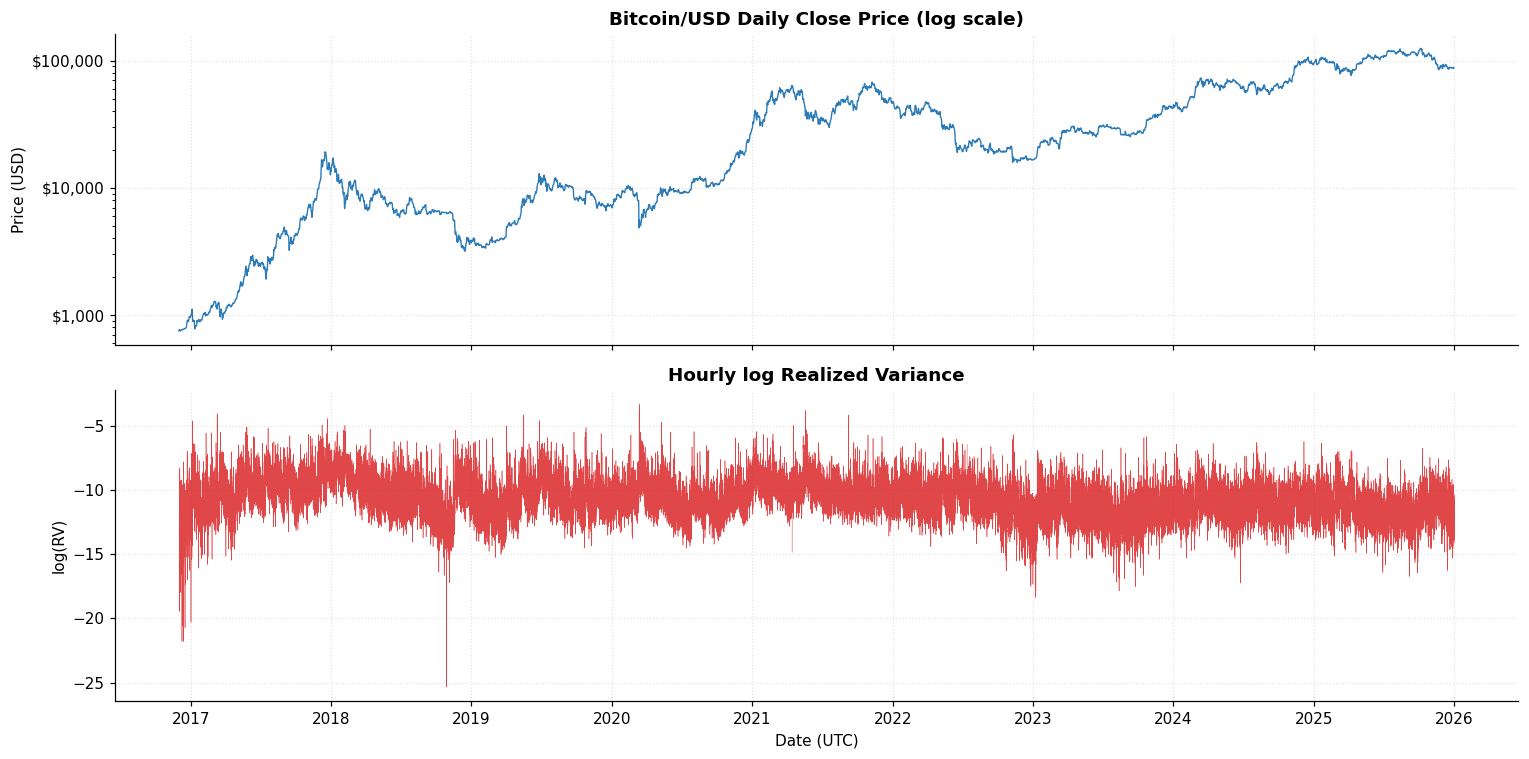

In [28]:
# Figure: Price + log_RV overview and Figure: Hourly Log Realized Variance 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
daily_px = raw["close"].resample("1D").last()

ax1.plot(daily_px.index, daily_px, color="#2C7BB6", lw=0.9)
ax1.set_yscale("log")
ax1.set_title("Bitcoin/USD Daily Close Price (log scale)",
              fontweight="bold")

ax1.set_ylabel("Price (USD)")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax2.plot(rv.index, rv["log_RV"], color="#D7191C", lw=0.35, alpha=0.8)
ax2.set_title("Hourly log Realized Variance",
              fontweight="bold")

ax2.set_ylabel("log(RV)")
ax2.set_xlabel("Date (UTC)")

plt.tight_layout()
plt.show()

In [29]:
# Descriptive statistics 

def desc_stats(s, name):
    s = s.dropna()
    jb_stat, jb_p = jarque_bera(s)
    return pd.Series({
        "N": len(s), "Mean": s.mean(), "Std": s.std(),
        "Skew": skew(s), "Kurt(ex)": kurtosis(s),
        "Min": s.min(), "Max": s.max(),
        "JB stat": jb_stat, "JB p": jb_p,
    }, name=name)
 
stats = pd.concat([desc_stats(returns, "5-min returns"),
                   desc_stats(rv_ser, "Hourly RV"),
                   desc_stats(logrv, "Hourly log_RV")], axis=1)

print("\n  Descriptive Statistics:")
print("  " + "─" * 65)
print(stats.round(4).to_string())
jb_rv  = jarque_bera(rv_ser.dropna())
jb_log = jarque_bera(logrv.dropna())
print(f"\n  log transformation reduces JB by {jb_rv[0]/jb_log[0]:.2e}×")
print("  *Supports log_RV as modelling target (near-Gaussian).") 


  Descriptive Statistics:
  ─────────────────────────────────────────────────────────────────
          5-min returns     Hourly RV  Hourly log_RV
N          8.757920e+05  7.961800e+04     79596.0000
Mean       0.000000e+00  1.000000e-04       -10.8724
Std        2.400000e-03  3.000000e-04         1.4649
Skew      -3.067000e-01  4.921410e+01         0.0210
Kurt(ex)   6.636090e+01  4.468349e+03         0.8485
Min       -1.030000e-01  0.000000e+00       -25.3541
Max        8.180000e-02  3.500000e-02        -3.3515
JB stat    1.607130e+08  6.626816e+10      2393.8085
JB p       0.000000e+00  0.000000e+00         0.0000

  log transformation reduces JB by 2.77e+07×
  *Supports log_RV as modelling target (near-Gaussian).


- Bitcoin's realized volatility (RV) exhibits a highly skewed and heavy-tailed distribution. While volatility remains low for extended periods, extreme events such as the LUNA/Terra collapse and the FTX crisis generate substantial volatility spikes. This behavior weakens the normality assumption underlying HAR and GARCH models and can reduce the reliability of parameter estimation and inference, particularly during periods of market stress.

- To mitigate this issue, a logarithmic transformation is applied to the RV series. Following the transformation, skewness decreases from 49.21 to 0.02, while kurtosis falls from 4468.35 to 0.85. In addition, the Jarque–Bera statistic declines by approximately 2.77 × 10⁷ times. These results indicate that the log-transformed series (log_RV) is much closer to a normal distribution, supporting its use as the modeling variable throughout this study.

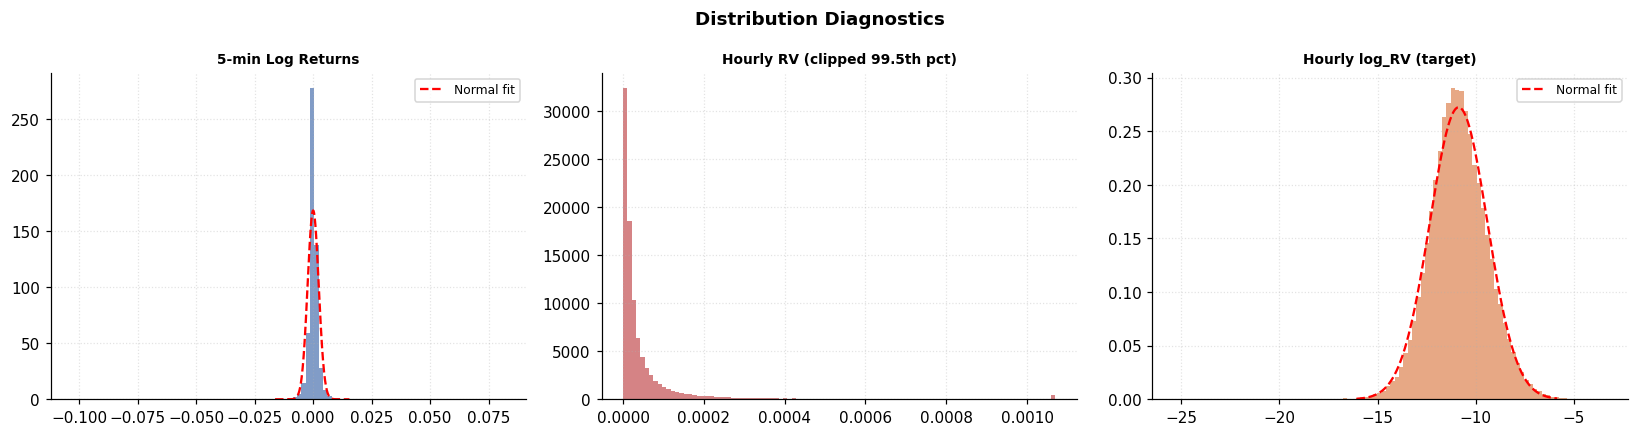

In [30]:
# Distribution diagnostics 

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ser, colour, title in [
    (axes[0], returns, "#4C72B0", "5-min Log Returns"),
    (axes[1], rv_ser.clip(upper=rv_ser.quantile(0.995)),
              "#C44E52", "Hourly RV (clipped 99.5th pct)"),
    (axes[2], logrv,   "#DD8452", "Hourly log_RV (target)"),
]:
    ax.hist(ser.dropna(), bins=100, density=True, color=colour, alpha=0.7)
    if title != "Hourly RV (clipped 99.5th pct)":
        xs = np.linspace(ser.dropna().quantile(0.001),
                         ser.dropna().quantile(0.999), 300)
        ax.plot(xs, _norm.pdf(xs, ser.mean(), ser.std()),
                "r--", lw=1.5, label="Normal fit")
        ax.legend(fontsize=8)
    ax.set_title(f"{title}", fontweight="bold", fontsize=9)
    
plt.suptitle("Distribution Diagnostics", fontweight="bold")
plt.tight_layout()
plt.show()

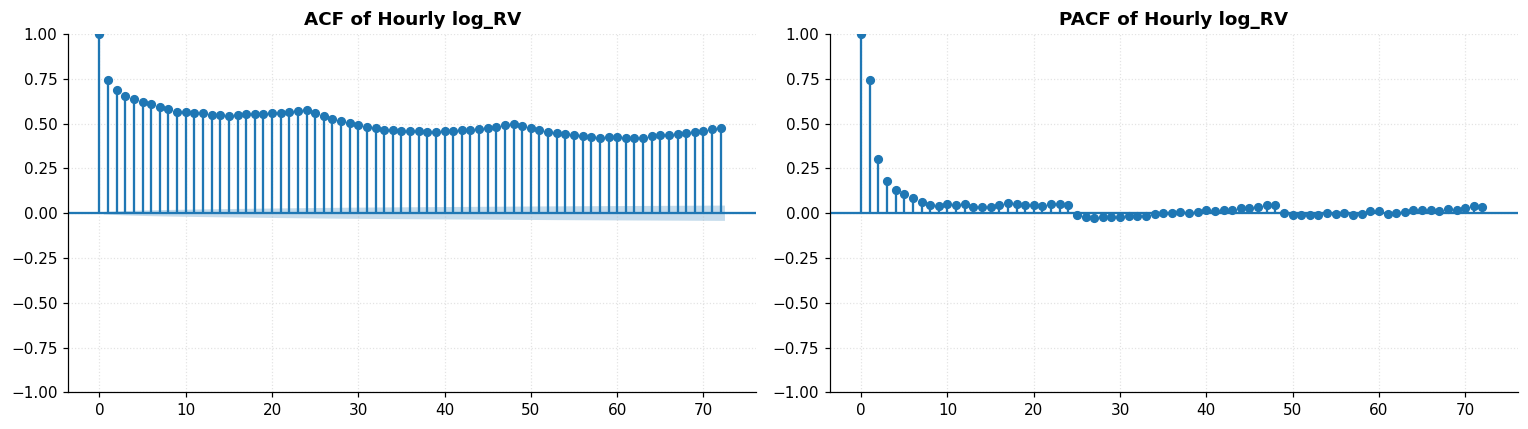

In [31]:
# ACF / PACF 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(logrv,  lags=72, alpha=0.05, ax=axes[0])
axes[0].set_title("ACF of Hourly log_RV", fontweight="bold")
plot_pacf(logrv, lags=72, method="ywm", alpha=0.05, ax=axes[1])
axes[1].set_title("PACF of Hourly log_RV", fontweight="bold")
plt.tight_layout()
plt.show()

- ##### ACF (Autocorrelation Function)

The ACF shows how strongly a time series is correlated with its own past values. In other words, it answers the question: *"How similar is today's log_RV to the value observed k hours ago?"*

In this case, the ACF starts at about 0.74 for lag 1 and remains significant even after 72 hours (3 days), where it is still around 0.50. This very slow decline indicates strong persistence over time. If the series were just random noise, the autocorrelations would quickly drop to zero. Instead, volatility remains highly correlated with its past values for several days.

In practical terms, when volatility becomes high, it tends to stay high for a long period rather than returning immediately to normal levels. This is a typical sign of long memory in volatility.

- ##### PACF (Partial Autocorrelation Function)

The PACF measures the direct relationship between the current value and a past value after removing the effects of the intermediate lags.

Here, the PACF is about 0.74 at lag 1 and drops to around 0.26 at lag 2. After lag 3, the values are close to zero. This suggests that the direct dependence is concentrated mainly in the first one or two lags.

- ##### What Do These Results Mean Together?

The combination of a slowly decaying ACF and a PACF that cuts off after lag 2 suggests that the apparent long memory is mainly driven by short-term dependencies that propagate through time.

In other words, today's volatility is strongly influenced by yesterday's volatility, which was influenced by the day before, and so on. The persistence observed over several days is therefore largely an indirect effect of these short-run relationships, rather than a direct influence of volatility from three days ago on today's volatility.


In [32]:
# Stationarity & ARCH 

adf = adfuller(logrv.dropna(), autolag="AIC")
print(f"\n  ADF test (log_RV): stat={adf[0]:.4f}  p={adf[1]:.4g}  "
      f"→ {'stationary' if adf[1] < 0.05 else 'non-stationary'}")
 
arch_test = het_arch(hourly_ret.dropna(), nlags=24)
print(f"  ARCH LM (24 lags): stat={arch_test[0]:.4f}  p={arch_test[1]:.4g}  "
      f" ARCH effects {'present' if arch_test[1] < 0.05 else 'absent'}")


  ADF test (log_RV): stat=-13.3256  p=6.331e-25  → stationary
  ARCH LM (24 lags): stat=9932.0097  p=0   ARCH effects present


##### ADF Test >>>> Is log_RV Stationary?
Result: stat = −13.33 | p ≈ 6.3 × 10⁻²⁵ →  Stationary

The null hypothesis of a unit root is decisively rejected.log_RV does not drift over time it fluctuates around a stable mean. This is a prerequisite for reliable OLS, GARCH, and LSTM estimation.

##### 2. ARCH LM Test >>> Does Volatility Cluster?
Result: stat = 9932 | p ≈ 0 →  ARCH effects present

The null hypothesis of constant variance is decisively rejected. Periods of high volatility tend to be followed by high volatility and vice versa.  This volatility clustering is the core motivation for the MC-GARCH model.

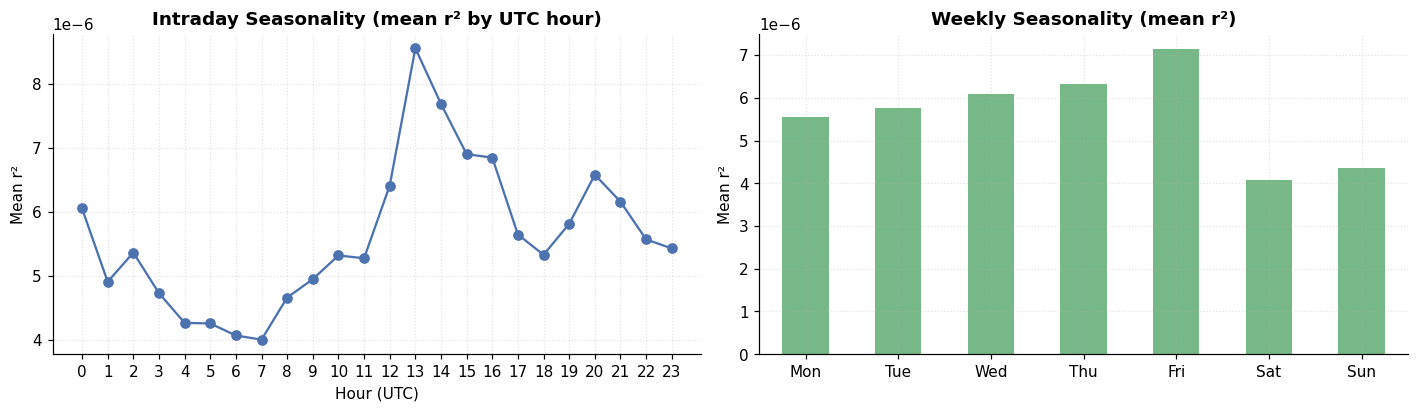

In [33]:
# Intraday / weekly seasonality 

intra = raw[["r2_5m"]].dropna().copy()
intra["hour_utc"] = intra.index.hour
intra["weekday"]  = intra.index.dayofweek
h_prof = intra.groupby("hour_utc")["r2_5m"].mean()
d_prof = intra.groupby("weekday")["r2_5m"].mean()
d_prof.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
h_prof.plot(marker="o", color="#4C72B0", lw=1.5, ax=axes[0])
axes[0].set_title("Intraday Seasonality (mean r² by UTC hour)",
                  fontweight="bold")

axes[0].set_xlabel("Hour (UTC)"); axes[0].set_ylabel("Mean r²")
axes[0].set_xticks(range(24))
d_prof.plot(kind="bar", color="#55A868", alpha=0.8, rot=0, ax=axes[1])
axes[1].set_title("Weekly Seasonality (mean r²)", fontweight="bold")
axes[1].set_ylabel("Mean r²")

plt.tight_layout()
plt.show()

- ##### Intraday Pattern

Bitcoin volatility follows a distinct daily cycle. The lowest volatility is observed around 07:00 UTC, when Asian markets are closing and European markets have not yet fully opened. Market activity is relatively subdued during this period, resulting in smaller price fluctuations.

Volatility rises throughout the day and reaches its peak around 13:00 UTC, nearly doubling its minimum level. This peak coincides with the London–New York market overlap, the most active trading window in global financial markets. The concentration of institutional trading and increased order flow during this period appears to spill over into the Bitcoin market, generating larger price movements.

- ##### Weekly Pattern

A similar pattern emerges across the week. Friday consistently records the highest volatility, likely reflecting institutional investors adjusting or unwinding positions before the weekend. Increased portfolio rebalancing and risk management activity contribute to stronger market fluctuations.

In contrast, Saturday and Sunday are the least volatile days of the week. Despite Bitcoin's continuous trading schedule, reduced participation from institutional investors during the weekend leads to lower market activity and calmer price dynamics.

- ##### Implications for Modelling

These recurring patterns indicate that calendar effects contain valuable predictive information and should be incorporated into volatility forecasting models. To capture these cyclical behaviors, the LSTM model includes time-based features:

* hour_sin and hour_cos represent intraday cycles and allow the model to learn hour-of-day effects.
* dow_sin and dow_cos represent weekly cycles and capture day-of-week seasonality.

By incorporating these features, the model can better account for systematic variations in volatility associated with trading activity across different hours and days.


## 3 — FEATURE ENGINEERING (MODEL-SPECIFIC)

In [34]:
EPS = 1e-12   # numerical floor for log transforms — prevents log(0) errors
df  = rv[["RV", "log_RV", "jump", "RS_minus"]].copy()

All features are constructed from the hourly RV series computed in Section 1.
Three nested feature sets are built in sequence — {HAR-Classic, HAR-Extended,
and LSTM} — each adding variables to the previous set. Every feature uses only
past information (shift(1) before any rolling window) so no look-ahead
bias is introduced.

In [35]:
#  3.1 HAR lags 

# Corsi (2009) log-linear HAR: regress log(RV_t) on log(RV_{t-k}).
# Fırst: compute LEVEL rolling means from t-1 backward (no leakage).
# Second: take log — this ensures the predictor and target share the same scale. Using level rv with a log target creates a scale mismat and produces pathologically large OLS coefficients.


df["RV_1h"] = df["RV"].shift(1)
df["RV_24h"] = df["RV"].shift(1).rolling(24).mean()
df["RV_168h"] = df["RV"].shift(1).rolling(168).mean()

df["log_RV_1h"] = np.log(df["RV_1h"].clip(lower=EPS))
df["log_RV_24h"] = np.log(df["RV_24h"].clip(lower=EPS))
df["log_RV_168h"] = np.log(df["RV_168h"].clip(lower=EPS))

The three HAR components are constructed as log-averages of past realized
variance at the hourly (1h), daily (24h), and weekly (168h) horizons:

$$\text{log\_RV\_1h}_t   = \log\, RV_{t-1}$$
$$\text{log\_RV\_24h}_t  = \log\!\left(\frac{1}{24}\sum_{k=1}^{24} RV_{t-k}\right)$$
$$\text{log\_RV\_168h}_t = \log\!\left(\frac{1}{168}\sum_{k=1}^{168} RV_{t-k}\right)$$

shift(1) is applied before every rolling window — the window looks
backward from $t-1$, never touching $t$. The clip(lower=EPS) guard
prevents $\log(0)$ on the 22 zero-RV hours.

In [36]:
#  3.2 Jump ratio — daily (Andersen et al. 2007)

# Proportion of total 24h variance attributable to discontinuous price jumps.
# Bounded in [0, 1] by construction; filled with 0 when RV sum is zero.

rv24_roll = df["RV"].shift(1).rolling(24).sum().replace(0, np.nan)

df["jump_24h"] = (df["jump"].shift(1).rolling(24).sum() / rv24_roll).fillna(0.0).clip(0, 1)

$$\text{jump\_24h}_t = \frac{\sum_{k=1}^{24} J_{t-k}}{\sum_{k=1}^{24} RV_{t-k}}, \qquad J_t = \max(RV_t - BPV_t,\ 0)$$

A value close to 1 indicates that most of the past day's variance came from
discontinuous price jumps; a value close to 0 indicates smooth, diffusive
variation. Filled with 0 when the denominator is zero (no trading activity).

In [37]:
#  3.3 Downside semivariance ratio — daily (Patton & Sheppard 2015)

# Proportion of total 24h variance attributable to negative returns.
# Bounded in [0, 1]; filled with 0.5 (symmetric prior) when RV sum is zero.

df["RS_minus_24h"] = (df["RS_minus"].shift(1).rolling(24).sum() / rv24_roll).fillna(0.5).clip(0, 1)

$$\text{RS\_minus\_24h}_t = \frac{\sum_{k=1}^{24} RS^-_{t-k}}{\sum_{k=1}^{24} RV_{t-k}}$$

Captures the asymmetric contribution of negative returns to total variance.
If downside volatility is systematically higher than upside volatility — a
common finding in equity markets — this ratio will exceed 0.5. The neutral
prior of 0.5 is used as a fill value when the denominator is zero.

In [38]:
#  3.4 Calendar features — cyclical encoding for only LSTM

# Sine/cosine encoding preserves the circular nature of time:
# hour 23 and hour 0 are adjacent in this representation.
# Integer labels (0–23, 0–6) would impose an artificial ordinal distance.

df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
df["dow_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)

Hours and weekdays are encoded as sine/cosine pairs:

$$\text{hour\_sin}_t = \sin\!\left(\frac{2\pi \cdot h_t}{24}\right), \quad
  \text{hour\_cos}_t = \cos\!\left(\frac{2\pi \cdot h_t}{24}\right)$$

$$\text{dow\_sin}_t  = \sin\!\left(\frac{2\pi \cdot d_t}{7}\right),  \quad
  \text{dow\_cos}_t  = \cos\!\left(\frac{2\pi \cdot d_t}{7}\right)$$

where $h_t \in \{0,\ldots,23\}$ and $d_t \in \{0,\ldots,6\}$.
These four features are included only in the LSTM specification — HAR's
linear regression cannot exploit nonlinear calendar interactions.

In [39]:
#  3.5 Clean up 

# Drop intermediate level-RV columns (not used as model features).
# Drop the first 190 rows created by the longest rolling window (168h).

df = df.drop(columns=["jump", "RS_minus", "RV_1h", "RV_24h", "RV_168h"])
n_before = len(df)
df = df.dropna()

print(f"\n  Feature matrix : {df.shape[0]:,} × {df.shape[1]} columns")
print(f" Dropped rows : {n_before - len(df)} (longest rolling = 168h)")
print(f" Columns : {list(df.columns)}")


  Feature matrix : 79,428 × 11 columns
 Dropped rows : 190 (longest rolling = 168h)
 Columns : ['RV', 'log_RV', 'log_RV_1h', 'log_RV_24h', 'log_RV_168h', 'jump_24h', 'RS_minus_24h', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [40]:
#  3.6 Feature–target correlations 

# Pearson r: linear association. Spearman ρ: monotonic association.
# Both reported large divergence would indicate strong nonlinearity.

print(f"\n  Feature–Target Correlations (vs log_RV):")
print(f"  {'Feature':<18} {'Pearson r':>10} {'Spearman ρ':>12}")
print("  " + "─" * 42)
for col in ALL_FEATS:
    if col not in df.columns: continue
    v = df[[col, "log_RV"]].dropna()
    rp, _ = pearsonr(v[col], v["log_RV"])
    rs, _ = spearmanr(v[col], v["log_RV"])
    print(f"  {col:<18} {rp:>10.4f} {rs:>12.4f}")


  Feature–Target Correlations (vs log_RV):
  Feature             Pearson r   Spearman ρ
  ──────────────────────────────────────────
  log_RV_1h              0.7375       0.7329
  log_RV_24h             0.7291       0.7125
  log_RV_168h            0.6588       0.6496
  jump_24h              -0.0367      -0.0179
  RS_minus_24h           0.0358       0.0389
  hour_sin              -0.1284      -0.1258
  hour_cos              -0.0449      -0.0516
  dow_sin                0.1416       0.1365
  dow_cos               -0.0328       0.0004


Pearson r and Spearman ρ are reported jointly. When both are similar the
relationship is approximately linear; large divergence would indicate
nonlinearity or outlier sensitivity.

**Findings:**

- **HAR lags (log\_RV\_1h/24h/168h):** Strong correlations in the 0.66–0.74
  range. The monotonic decrease with horizon length is the empirical signature
  of volatility persistence and directly motivates the HAR model's
  multi-horizon structure.

- **jump\_24h and RS\_minus\_24h:** Correlations ≈ ±0.04 — negligible linear
  association with the target. This already hints that HAR-Extended will not
  materially improve on HAR-Classic, a finding confirmed by the DM test
  (p = 0.0004, Section 11).

- **Calendar features (hour\_sin/cos, dow\_sin/cos):** Weak but non-zero
  (0.03–0.14). Too small to benefit a linear HAR regression, but SHAP
  analysis (Section 9) shows hour\_cos ranking third in LSTM feature
  importance — the LSTM exploits these signals through nonlinear interactions
  that OLS cannot capture.

In [41]:
#  3.7 Variance Inflation Factors (*multicollinearity check*) 

# VIF_j = 1 / (1 - R²_j), where R²_j is the R² from regressing feature j
# on all other features. VIF > 10: severe; VIF > 5: moderate concern.
# We check HAR + Extended features only (calendar features are orthogonal
# by construction — sin/cos pairs have zero cross-correlation).

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = HAR_CLASSIC_FEATS + ["jump_24h", "RS_minus_24h"]
vif_data = df[vif_cols].dropna()
vif = pd.DataFrame({
    "Feature": vif_cols,
    "VIF"  : [variance_inflation_factor(vif_data.values, i)
                for i in range(len(vif_cols))]
})


print("\n  Variance Inflation Factors:")
print("  " + "─" * 30)
print(vif.to_string(index=False))
print("\n  Rule of thumb: VIF > 10  >>> severe multicollinearity")
print(" VIF 5–10  >>> moderate multicollinearity")
print(" VIF < 5  >>> acceptable")


  Variance Inflation Factors:
  ──────────────────────────────
     Feature        VIF
   log_RV_1h 127.569962
  log_RV_24h 336.997631
 log_RV_168h 287.192622
    jump_24h   5.858629
RS_minus_24h  20.571161

  Rule of thumb: VIF > 10  >>> severe multicollinearity
 VIF 5–10  >>> moderate multicollinearity
 VIF < 5  >>> acceptable


The extreme VIF values for the three HAR lags are expected and by design,
not a modelling problem. log_RV_1h, log_RV_24h, and Log_RV_168h are
overlapping rolling averages of the same underlying series — log_RV_24h
already contains the 24 most recent values that log_RV_1h belongs to, and
log_RV_168h contains all values that log_RV_24h belongs to. Mechanical
collinearity is therefore unavoidable.

Crucially, this does not invalidate the HAR model for two reasons:

1. **OLS remains unbiased and consistent** even under perfect multicollinearity
   as long as the design matrix is not rank-deficient — which it is not here,
   since the three lags are not identical, only highly correlated.
2. **The HAR model is not used for variable selection or causal inference.**
   The research question is predictive accuracy, not the individual
   contribution of each lag. Inflated standard errors reduce the precision of
   individual coefficient estimates, but they do not affect forecast quality —
   which is evaluated exclusively through RMSE, QLIKE, and the
   Diebold-Mariano test.

This interpretation is consistent with the HAR literature: Corsi (2009) and
subsequent applications routinely estimate HAR on overlapping lag components
without treating multicollinearity as a barrier to inference.

RS_minus_24h (VIF = 20.6) shows moderate-to-severe collinearity. As noted
in Section 3.6, RS_minus_24h is constructed from RS_minus, which is a
component of RV itself — structural overlap with log_RV_1h/24h is
unavoidable and explains the elevated VIF. Combined with its near-zero
target correlation (|r| < 0.04), this supports treating the HAR-Extended
specification primarily as a robustness check rather than a structural
improvement.

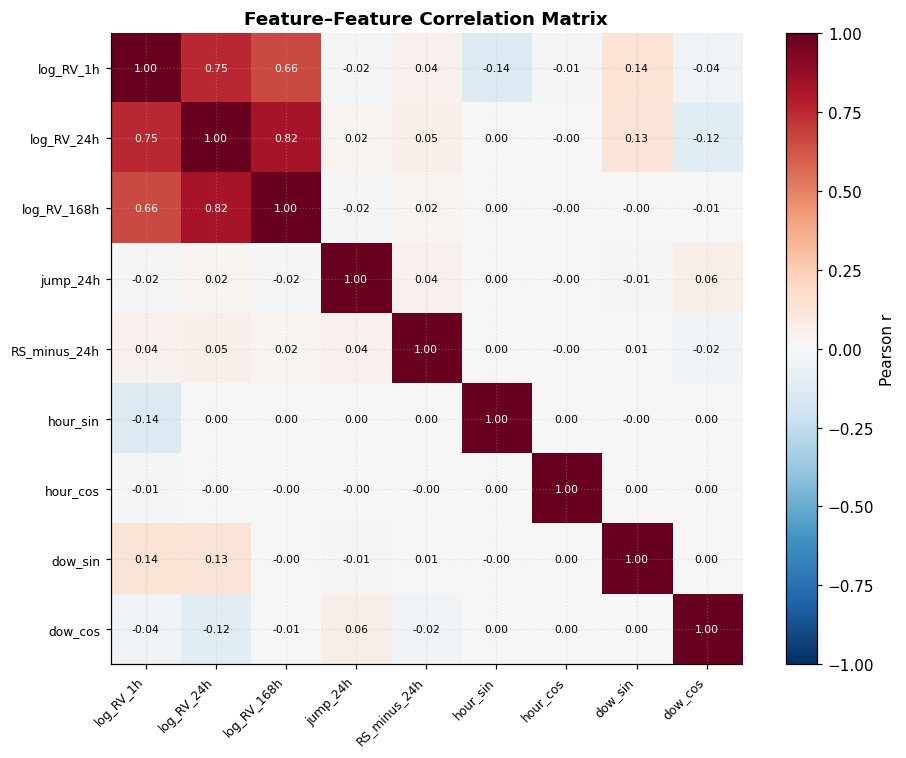

In [42]:
#  3.8 Feature–feature correlation heatmap 

fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[ALL_FEATS].corr()
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(ALL_FEATS)))
ax.set_xticklabels(ALL_FEATS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(ALL_FEATS)))
ax.set_yticklabels(ALL_FEATS, fontsize=8)
for i in range(len(ALL_FEATS)):
    for j in range(len(ALL_FEATS)):
        v = corr_matrix.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(v) > 0.6 else "black")
        
ax.set_title("Feature–Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

In [43]:
print("\n  Feature–Feature Correlation Matrix:")
print("  " + "─" * (18 * len(ALL_FEATS) + 4))
header = f"  {'':18}" + "".join(f"{c:>10}" for c in ALL_FEATS)
print(header)
print("  " + "─" * len(header))
for row_feat in ALL_FEATS:
    row = f"  {row_feat:<18}"
    for col_feat in ALL_FEATS:
        v = corr_matrix.loc[row_feat, col_feat]
        row += f"{v:>10.3f}"
    print(row)


  Feature–Feature Correlation Matrix:
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                     log_RV_1hlog_RV_24hlog_RV_168h  jump_24hRS_minus_24h  hour_sin  hour_cos   dow_sin   dow_cos
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  log_RV_1h              1.000     0.751     0.658    -0.021     0.041    -0.135    -0.008     0.139    -0.036
  log_RV_24h             0.751     1.000     0.824     0.019     0.052     0.001    -0.004     0.132    -0.116
  log_RV_168h            0.658     0.824     1.000    -0.016     0.016     0.000    -0.000    -0.002    -0.005
  jump_24h              -0.021     0.019    -0.016     1.000     0.040     0.003    -0.001    -0.010     0.061
  RS_minus_24h           0.041     0.052     0.016     0.040     1.000     0.000    -0.003     0.007    -0.025
  hour_

**HAR lags (log\_RV\_1h / 24h / 168h):** Pairwise correlations of 0.66–0.82,
reflecting the overlapping nature of rolling averages computed on the same
series. This is the source of the high VIF values in Section 3.7 and is
expected by construction.

**Calendar features (hour\_sin/cos, dow\_sin/cos):** All cross-correlations
are effectively zero. Sine/cosine pairs encoding different cycles are
orthogonal by construction this is the principal advantage of cyclical
encoding over integer labels, which would introduce artificial ordinal
correlations.

**HAR lags vs. calendar features:** The only non-negligible off-block
correlation is log\_RV\_1h × hour\_sin = −0.135, reflecting the intraday
seasonality identified in Section 2: volatility is systematically lower
in the early UTC hours (low hour\_sin) and higher around the London–New York
overlap (high hour\_sin). This is a genuine market structure signal rather
than a multicollinearity concern.

**jump\_24h and RS\_minus\_24h** are effectively uncorrelated with all other
features (|r| < 0.06 everywhere off-diagonal), confirming that their
near-zero predictive signal (Section 3.6) is not an artifact of collinearity
suppression — they simply carry little information about future log\_RV.

## 4 — TRAIN / VAL / TEST SPLIT

In [44]:
train = df[df.index <= TRAIN_END]
val = df[(df.index > TRAIN_END) & (df.index <= VAL_END)]
test = df[df.index > VAL_END]
 
assert train.index.max() < val.index.min(),  "Train/Val overlap"
assert val.index.max()   < test.index.min(), "Val/Test overlap"
 
print(f"\n  {'Split':<14} {'Period':<28} {'Hours':>8}  {'%':>5}")
print("  " + "─" * 58)
for name, s, period in [
    ("Train", train, f"{train.index.min().date()} → {train.index.max().date()}"),
    ("Validation", val,   f"{val.index.min().date()} → {val.index.max().date()}"),
    ("Test", test,  f"{test.index.min().date()} → {test.index.max().date()}"),
]:
    print(f"  {name:<14} {period:<28} {len(s):>8,} {len(s)/len(df)*100:>5.1f}%")


  Split          Period                          Hours      %
  ──────────────────────────────────────────────────────────
  Train          2016-12-08 → 2021-12-31        44,376  55.9%
  Validation     2022-01-01 → 2023-12-31        17,512  22.0%
  Test           2024-01-01 → 2025-12-31        17,540  22.1%


**Train (2016-12-08 → 2021-12-31, 55.9%):** Five years covering Bitcoin's full early regime
spectrum the 2017 ICO bull run, 2018 bear market, COVID crash and recovery, and the 2021
ATH. The start date is 2016-12-08 rather than 2016-12-01 because the 168-hour HAR lag
requires one week of warm-up observations before producing its first valid value.

**Validation (2022-01-01 → 2023-12-31, 22.0%):** Deliberately the two most stressful years
in the sample the LUNA/Terra collapse (May 2022), the FTX bankruptcy (November 2022), and
the prolonged bear market that followed. Walk-forward CV is conducted over this period,
providing a demanding out-of-sample stress test for hyperparameter selection and model
comparison.

**Test (2024-01-01 → 2025-12-31, 22.1%):** A structurally distinct out-of-sample period,
spanning the spot Bitcoin ETF approval (January 2024) and the halving event (April 2024).
Models never see this data during training or validation. The regime difference between the
stressed validation window and the comparatively calm test period is the primary driver of
the WFV-to-test QLIKE gap discussed in Section 10.

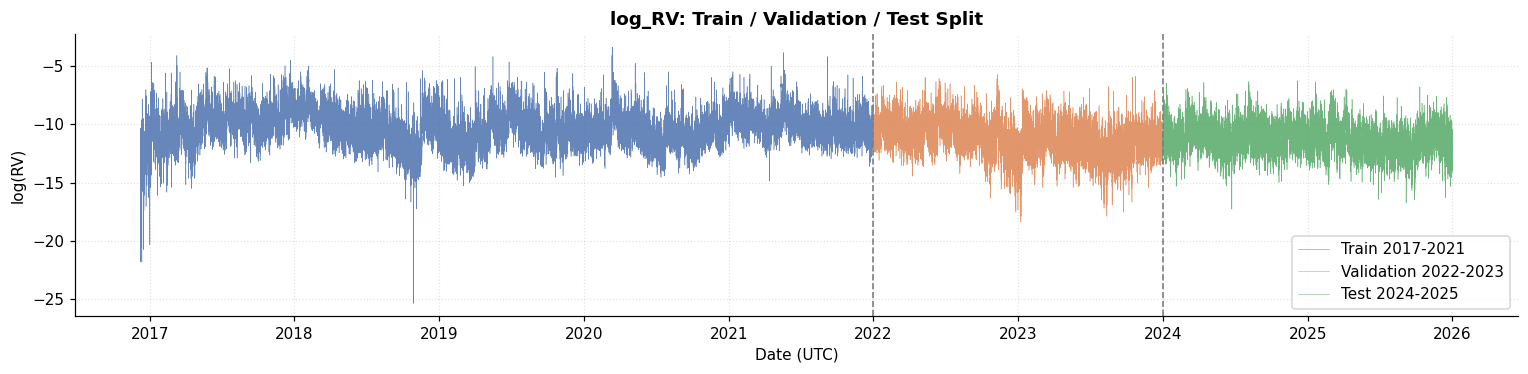

In [45]:
# Split visualisation
fig, ax = plt.subplots(figsize=(14, 3.5))
for s, colour, lbl in [
    (train, "#4C72B0", "Train 2017-2021"),
    (val,   "#DD8452", "Validation 2022-2023"),
    (test,  "#55A868", "Test 2024-2025"),
]:
    ax.plot(s.index, s["log_RV"], color=colour, lw=0.35, alpha=0.85, label=lbl)
ax.axvline(TRAIN_END, color="gray", lw=1.1, ls="--")
ax.axvline(VAL_END,   color="gray", lw=1.1, ls="--")
ax.set_title("log_RV: Train / Validation / Test Split",
             fontweight="bold")

ax.set_ylabel("log(RV)"); ax.set_xlabel("Date (UTC)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5 — EVALUATION & UTILITY FUNCTIONS

In [46]:
# QLIKE floor: numerical guard against near-zero predicted variance (Patton 2011). Set to the 0.1th percentile of positive training RV to avoid log(0) or division
# by zero without materially affecting the loss for well-calibrated forecasts.

QLIKE_FLOOR = float(train["RV"][train["RV"] > 0].quantile(0.001))

- A small numerical floor is applied to predicted RV before computing QLIKE,
following Patton (2011). This prevents division-by-zero when a model produces
a near-zero forecast, without meaningfully affecting the loss for any
well-calibrated model.

In [47]:
def qlike(rv_true, rv_pred):
    """
    QLIKE loss in RV space (Patton 2011).

    Asymmetric loss function that penalises under-prediction of volatility
    spikes more heavily than over-prediction — appropriate for risk management
    applications where failing to anticipate a spike is costly.

        QLIKE = mean(r - log(r) - 1),  r = RV_true / RV_pred

    A floor is applied to RV_pred to avoid numerical instability.
    """
    rp = np.maximum(np.asarray(rv_pred, float), QLIKE_FLOOR)
    rt = np.asarray(rv_true, float)
    r  = rt / rp
    return float(np.mean(r - np.log(r) - 1))

- QLIKE is an asymmetric loss function defined in RV space. Unlike MSE, whichnpenalises over- and under-prediction equally, QLIKE is convex in the ration$RV_t / \hat{RV}_t$ and penalises under-prediction of volatility spikes more heavily. This makes it the standard evaluation metric in the realized volatility
forecasting literature (Patton 2011; Hansen & Lunde 2006).

In [48]:
def mape(y_true, y_pred):
    """
    Mean Absolute Percentage Error — reported for interpretability only.
    Near-zero actuals are excluded to avoid division instability.
    """
    mask = np.abs(y_true) > 1e-10
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

- MAPE is included as a scale-free, human-interpretable complement to RMSE.
Observations where the actual value is effectively zero are excluded to
prevent numerical instability; these correspond to the 22 zero-RV hours
already set to NaN elsewhere.

In [49]:
def compute_metrics(y_true_log, y_pred_log, model_name):
    """
    Evaluate a model on both the log_RV and RV scales.

    RV-scale point forecast: RV_hat = exp(log_RV_hat) — the median forecast
    implied by a log-normal model for RV (Patton 2011). This single formula
    is applied identically to every model (Random Walk through LSTM) and to
    both WFV and test evaluation. No Jensen/mean correction is applied; see
    Section 8.5 for a diagnostic comparing median vs mean forecasts for
    MC-GARCH specifically.

    Returns: (log_metrics dict, rv_metrics dict, rv_pred array)
    """
    yt = np.asarray(y_true_log, float)
    yp = np.asarray(y_pred_log, float)

    # log_RV scale
    rmse_l = float(np.sqrt(mean_squared_error(yt, yp)))
    mae_l = float(mean_absolute_error(yt, yp))
    mape_l = mape(yt, yp)
    r2_l   = float(r2_score(yt, yp))

    # RV scale — median forecast, no Jensen correction
    yt_rv = np.exp(yt)
    yp_rv = np.exp(yp)
    rmse_rv = float(np.sqrt(mean_squared_error(yt_rv, yp_rv)))
    mae_rv = float(mean_absolute_error(yt_rv, yp_rv))
    ql  = qlike(yt_rv, yp_rv)

    lm = {"RMSE": rmse_l, "MAE": mae_l, "MAPE": mape_l, "R2": r2_l}
    rm = {"RMSE": rmse_rv, "MAE": mae_rv, "QLIKE": ql}

    # I inspired this print formating from a llm 
    print(f"\n  ┌─ {model_name} " + "─" * (54 - len(model_name)))
    print(f"  │  log_RV: RMSE={rmse_l:.5f}  MAE={mae_l:.5f}  "
          f"MAPE={mape_l:.2f}%  R²={r2_l:.4f}")
    print(f"  │  RV    : RMSE={rmse_rv:.3e}  MAE={mae_rv:.3e}  "
          f"QLIKE={ql:.6f}")
    print(f"  └{'─'*58}")
    return lm, rm, yp_rv

- `compute_metrics` evaluates every model on two scales. On the **log_RV scale**,
RMSE, MAE, MAPE and R² are computed directly on the model's output. On the
**RV scale**, the log forecast is back-transformed via $\hat{RV}_t =
\exp(\widehat{\log RV}_t)$ — the median forecast under log-normality — and
RMSE, MAE and QLIKE are computed on the resulting level series. Using a single,
model-agnostic back-transformation ensures that the QLIKE figures in Section 10
are directly comparable across all models and across WFV and test periods.

In [50]:
def mz_regression(y_true, y_pred, model_name=""):
    """
    Mincer-Zarnowitz (1969) forecast unbiasedness regression.

    Regresses actual log_RV on predicted log_RV:
        log_RV_t = alpha + beta * log_RV_hat_t + epsilon_t

    An unbiased, efficient forecast implies alpha = 0 and beta = 1.
    The joint hypothesis H0: (alpha, beta) = (0, 1) is tested via an
    F-statistic; rejection indicates systematic bias in the forecast.
    """
    n    = len(y_true)
    X    = np.column_stack([np.ones(n), y_pred])
    b    = np.linalg.lstsq(X, y_true, rcond=None)[0]
    yh   = X @ b
    sse  = np.sum((y_true - yh) ** 2)
    sst  = np.sum((y_true - y_true.mean()) ** 2)
    r2   = 1 - sse / sst
    s2   = sse / (n - 2)
    XtXi = np.linalg.inv(X.T @ X)
    R, r = np.array([[1, 0], [0, 1]]), np.array([0.0, 1.0])
    Rbr  = R @ b - r
    Fstat = (Rbr @ np.linalg.inv(R @ XtXi @ R.T) @ Rbr) / (2 * s2)
    Fpval = 1 - f_dist.cdf(Fstat, 2, n - 2)
    if model_name:
        bias = "UNBIASED" if Fpval >= 0.05 else "BIASED"
        print(f"  MZ: α={b[0]:.4f}  β={b[1]:.4f}  R²={r2:.4f}  "
              f"F={Fstat:.2f}  p={Fpval:.3g}  [{bias}]")
    return {"alpha": b[0], "beta": b[1], "R2": r2, "F": Fstat, "p": Fpval}

- The Mincer-Zarnowitz regression tests whether a forecast is systematically
biased. A perfectly calibrated forecast satisfies $\alpha = 0$ and $\beta = 1$
jointly meaning actual volatility equals predicted volatility on average,
with no over- or under-prediction across the forecast range. The F-test for
this joint hypothesis is standard in the forecast evaluation literature
(Mincer & Zarnowitz 1969; Patton & Sheppard 2009).

In [51]:
def make_wfv_splits(data):
    """
    Expanding-window walk-forward validation splits.

    Each fold k adds one chunk of observations to the training set and
    evaluates on the next chunk, so training always precedes evaluation
    in calendar time no look-ahead bias.

    chunk = (n_tot - n_min) // WFV_N_SPLITS ensures the five folds
    together cover the full validation period (Jan 2022 – Dec 2023),
    matching the fold definition used in the R MC-GARCH script.
    """
    n_min  = len(train)
    n_tot  = len(data)
    chunk  = (n_tot - n_min) // WFV_N_SPLITS
    splits = []
    for k in range(WFV_N_SPLITS):
        te = n_min + k * chunk
        ve = te + chunk
        if ve > n_tot: break
        splits.append((data.iloc[:te], data.iloc[te:ve]))
    return splits

- ***make_wfv_splits*** implements expanding-window walk-forward validation: each
fold retrains the model on all available history up to that point and evaluates
on the immediately following period, respecting the temporal ordering of the
data. Five folds are created such that they jointly span the full 2022–2023
validation window the same fold boundaries used in the R MC-GARCH script,
ensuring cross-model WFV comparisons are computed on identical date ranges.

In [52]:
def store(model_name, lm, rm, mz):
    """Write model metrics to the global result stores for Section 10/11."""
    lm["MZ"] = mz
    all_metrics["log_RV"][model_name] = lm
    all_metrics["RV"][model_name]     = rm

def plot_forecast_vs_actual(idx, y_true, y_pred, model_name, colour):
    """Forecast vs actual log_RV and residuals — side-by-side panel."""
    resid = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(idx, y_true, color="#999999", lw=0.4, alpha=0.7,
                 label="Actual log_RV")
    axes[0].plot(idx, y_pred, color=colour, lw=0.8, alpha=0.9,
                 label=f"{model_name} forecast")
    axes[0].set_title(f"{model_name}: Forecast vs Actual (Test Period, 2024-2025)",
                      fontweight="bold")
    axes[0].set_ylabel("log(RV)"); axes[0].legend(fontsize=8)
    axes[1].plot(idx, resid, color=colour, lw=0.4, alpha=0.7)
    axes[1].axhline(0, color="black", lw=0.8, ls="--")
    axes[1].set_title(f"{model_name}: Forecast Residuals", fontweight="bold")
    axes[1].set_ylabel("Residual")
    plt.tight_layout(); plt.show()

def plot_error_dist(resid, model_name, colour):
    """Residual histogram with normal overlay and QQ-plot."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(resid, bins=60, density=True, color=colour, alpha=0.7)
    xs = np.linspace(resid.min(), resid.max(), 300)
    axes[0].plot(xs, _norm.pdf(xs, resid.mean(), resid.std()),
                 "r--", lw=1.5, label="Normal fit")
    axes[0].axvline(0, color="black", lw=0.8)
    axes[0].set_title(f"{model_name}: Residual Distribution", fontweight="bold")
    axes[0].legend(fontsize=8)
    from scipy.stats import probplot
    probplot(resid, plot=axes[1])
    axes[1].set_title(f"{model_name}: Residual QQ-Plot", fontweight="bold")
    plt.tight_layout(); plt.show()

def print_overfit_summary(model_name, train_metric, val_metric,
                          test_metric, metric_name="RMSE"):
    """
    Bias-variance / overfitting diagnosis.
    Compares train, validation and test RMSE to flag underfitting,
    mild overfitting, or good generalisation.
    """
    gap_tv = val_metric  - train_metric
    gap_vt = test_metric - val_metric
    print(f"\n  Overfitting Analysis [{model_name}]:")
    print(f"    Train {metric_name} : {train_metric:.5f}")
    print(f"    Val   {metric_name} : {val_metric:.5f}  (gap = {gap_tv:+.5f})")
    print(f"    Test  {metric_name} : {test_metric:.5f}  (gap = {gap_vt:+.5f})")
    if gap_tv > 0.05 * train_metric:
        verdict = "Mild overfitting (val > train)"
    elif val_metric > 1.5 * train_metric:
        verdict = "Strong overfitting"
    elif train_metric > 2 * val_metric:
        verdict = "Underfitting (high train error)" # a warning for myself
    else:
        verdict = "Generalises well"
    print(f"    Verdict : {verdict}")

Four lightweight helper functions used throughout Sections 6–9. `store` writes
each model's metrics into the global dictionaries for the Section 10 comparison
tables. `plot_forecast_vs_actual` and `plot_error_dist` produce the per-model
diagnostic figures. `print_overfit_summary` flags generalisation behaviour by
comparing train, validation and test RMSE — a gap of more than 5% between
validation and training error is classified as mild overfitting (a warning for myself).

## 6 — NAIVE BENCHMARKS

In [53]:
#  Ground truth arrays 

train_val  = pd.concat([train, val]).sort_index()
test_full  = test
y_true_log = test["log_RV"].values
test_index = test.index

Three arrays are initialised before any model is fitted.

`train_val` pools the full 2016–2023 history (train + validation) and is
used for the final HAR and MC-GARCH fits — both models are re-estimated on
this combined dataset before generating test-period forecasts.

`y_true_log` holds the test-period log_RV actuals (2024-01-01 → 2025-12-31,
17,540 hours) and serves as the shared evaluation target for every model.

`test_index` is the corresponding datetime index, used for series alignment
and plotting throughout Sections 7–10.

**Alignment note.** HAR and MC-GARCH produce a forecast for all 17,540 test
hours starting from 2024-01-01. LSTM cannot make its first prediction until
it has seen 168 hours of input, so its test series starts around 2024-01-08
and contains 17,372 forecasts — 168 fewer than HAR and MC-GARCH. The
Diebold-Mariano tests in Section 11 handle this by truncating every model's
error series to the same 17,372-hour window before any pairwise comparison,
ensuring that all accuracy differences reflect forecast quality rather than
differences in the evaluation period.

In [54]:
#  Naive benchmarks 

# Random Walk   : ŷ_t = y_{t-1}  (no-change forecast)
# Historical Mean: ŷ_t = mean(train log_RV)  (constant unconditional forecast)
# Both serve as lower-bound baselines. Any model that fails to beat them
# on RMSE and QLIKE provides no practical value over a trivial forecast.

y_rw = df["log_RV"].shift(1).reindex(test_index).values
y_hm = np.full(len(test_index), train["log_RV"].mean())

for name, ypred in [("Random Walk", y_rw), ("Historical Mean", y_hm)]:
    lm, rm, yp_rv = compute_metrics(y_true_log, ypred, name)
    mz = mz_regression(y_true_log, ypred, name)
    store(name, lm, rm, mz)
    predictions["log_RV"][name] = ypred
    predictions["RV"][name]     = yp_rv
    dm_errors[name]             = (y_true_log - ypred) ** 2

print(f"\n  Train mean log_RV = {train['log_RV'].mean():.4f}")


  ┌─ Random Walk ───────────────────────────────────────────
  │  log_RV: RMSE=0.95177  MAE=0.73839  MAPE=6.65%  R²=0.4046
  │  RV    : RMSE=6.446e-05  MAE=1.982e-05  QLIKE=0.740530
  └──────────────────────────────────────────────────────────
  MZ: α=-3.3964  β=0.7024  R²=0.4932  F=1532.35  p=1.11e-16  [BIASED]

  ┌─ Historical Mean ───────────────────────────────────────
  │  log_RV: RMSE=1.57041  MAE=1.28621  MAPE=10.85%  R²=-0.6209
  │  RV    : RMSE=5.902e-05  MAE=2.657e-05  QLIKE=0.827298
  └──────────────────────────────────────────────────────────
  MZ: α=-0.1038  β=1.0832  R²=-0.0000  F=5462.62  p=1.11e-16  [BIASED]

  Train mean log_RV = -10.4386


**Random Walk** predicts that next hour's log_RV equals the current hour's
value. It achieves RMSE=0.952 and QLIKE=0.741 non-trivial results given
that log_RV is strongly autocorrelated, so simply repeating yesterday's value
already explains roughly half the test variance (R²=0.493). The MZ regression
(α=−3.40, β=0.70, p≈0) confirms systematic bias: it under-predicts during
high-volatility spikes and over-predicts during calm periods, the expected
failure mode of a no-change forecast applied to a mean-reverting series.

**Historical Mean** predicts the unconditional training mean (−10.44) for
every hour without any time variation. Its R²=−0.621 worse than a
horizontal line through the test mean and QLIKE=0.827 (the highest of all
models) confirm that ignoring volatility clustering entirely is the worst
forecasting strategy in this dataset.

## 7 — HAR MODELS

In [55]:
# HAR-Classic (Corsi 2009): log-linear OLS with 3 lag features.
# HAR-Extended (Andersen 2007, Patton & Sheppard 2015): + jump + semivariance.

In [56]:
#  WFV data setup 

# wfv_data spans train+val (2016-2023); make_wfv_splits partitions it into
# five expanding-window folds, reused by both HAR specifications below.

wfv_data = pd.concat([train, val]).sort_index()
wfv_splits = make_wfv_splits(wfv_data)

#### 7.1 — HAR-Classic

In [57]:
#  HAR-Classic: Fit & Metrics 

# Corsi (2009) log-linear specification: log_RV regressed on three lagged
# log-RV components (hourly, daily, weekly). Fitted on train+val, evaluated on the held-out test set.

model_name = "HAR-Classic"
feats = HAR_CLASSIC_FEATS

m = LinearRegression()
m.fit(train_val[feats].values, train_val["log_RV"].values)

y_pred_classic = m.predict(test[feats].values)
y_pred_train = m.predict(train[feats].values)
y_pred_val = m.predict(val[feats].values)
rmse_train_c = float(np.sqrt(mean_squared_error(train["log_RV"], y_pred_train)))
rmse_val_c = float(np.sqrt(mean_squared_error(val["log_RV"],   y_pred_val)))

print(f" Coefficients [HAR-Classic]:")
print(f" {'Intercept':<20}: {m.intercept_:>9.4f}")
for f, c in zip(feats, m.coef_):
    print(f" {f:<20}: {c:>9.4f}")

lm, rm, yp_rv = compute_metrics(y_true_log, y_pred_classic, model_name)
mz = mz_regression(y_true_log, y_pred_classic, model_name)
store(model_name, lm, rm, mz)
predictions["log_RV"][model_name] = y_pred_classic
predictions["RV"][model_name] = yp_rv
dm_errors[model_name] = (y_true_log - y_pred_classic) ** 2

print_overfit_summary(model_name, rmse_train_c, rmse_val_c, lm["RMSE"])

 Coefficients [HAR-Classic]:
 Intercept           :   -0.2698
 log_RV_1h           :    0.3859
 log_RV_24h          :    0.4093
 log_RV_168h         :    0.2095

  ┌─ HAR-Classic ───────────────────────────────────────────
  │  log_RV: RMSE=0.86740  MAE=0.67219  MAPE=6.08%  R²=0.5055
  │  RV    : RMSE=5.409e-05  MAE=1.577e-05  QLIKE=0.593724
  └──────────────────────────────────────────────────────────
  MZ: α=0.5078  β=1.0428  R²=0.5066  F=19.25  p=4.47e-09  [BIASED]

  Overfitting Analysis [HAR-Classic]:
    Train RMSE : 0.89279
    Val   RMSE : 0.96423  (gap = +0.07144)
    Test  RMSE : 0.86740  (gap = -0.09683)
    Verdict : Mild overfitting (val > train)


- The estimated coefficients (0.386, 0.409, 0.210) sum to approximately 1.0, matching the theoretical expectation in Corsi (2009) that the three
heterogeneous volatility components average to a unit-weight decomposition of total persistence. The daily component (β=0.409) carries the largest
weight, followed by the hourly (β=0.386) and weekly (β=0.210) components indicating that Bitcoin's volatility memory is concentrated at short-to-medium
horizons rather than dominated by any single lag.

- On the test set the model achieves RMSE=0.867 and QLIKE=0.594. The MZ slope (β=1.043) is close to the ideal value of 1, but the joint unbiasedness test
is firmly rejected (p=4.5e-09) a small but statistically robust systematic bias is present (examined in detail after the WFV results below).

- The validation RMSE (0.964) exceeds the training RMSE (0.893), which the automated diagnostic flags as "mild overfitting." This label should be read with caution here: HAR-Classic has only three free parameters and is structurally unlikely to overfit at this sample size. The gap is better explained by the 2022–2023 validation window being a materially more
volatile period than 2016–2021 a regime effect, not a model-complexity effect, as the WFV fold analysis below confirms directly.

In [58]:
#  HAR-Classic: WFV 

# Five-fold expanding-window validation. Each fold reports RMSE, MAE, QLIKE (median-forecast, no Jensen correction — see Section 5) and the 
# fold's mean log_RV as a regime indicator. An automated check flags any fold whose QLIKE exceeds 3x the cross-fold median as a potential outlier.

print(f" WFV ({WFV_N_SPLITS} folds) — HAR-Classic:")
fold_rows = []
for k, (tr, va) in enumerate(wfv_splits):
    mk = LinearRegression()
    mk.fit(tr[HAR_CLASSIC_FEATS].values, tr["log_RV"].values)
    yp = mk.predict(va[HAR_CLASSIC_FEATS].values)
    yt = va["log_RV"].values
    fold_rows.append({
        "fold": k + 1,
        "period": f"{va.index.min().date()}\u2192{va.index.max().date()}",
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "MAE": float(mean_absolute_error(yt, yp)),
        "QLIKE": qlike(np.exp(yt), np.exp(yp)),
        "mean_logRV": float(va["log_RV"].mean()),
    })
    print(f" Fold {k+1} [{fold_rows[-1]['period']}]  "
          f"RMSE={fold_rows[-1]['RMSE']:.4f}  QLIKE={fold_rows[-1]['QLIKE']:.4f}  "
          f"(regime \u03bc={fold_rows[-1]['mean_logRV']:.2f})")

fdf_classic = pd.DataFrame(fold_rows).set_index("fold")
wfv_results["HAR-Classic"] = {
    "folds": fdf_classic,
    "mean": fdf_classic[["RMSE","MAE","QLIKE"]].mean(),
    "std": fdf_classic[["RMSE","MAE","QLIKE"]].std(),
}

print(f" WFV mean   QLIKE = {fdf_classic['QLIKE'].mean():.4f} "
      f"(\u00b1{fdf_classic['QLIKE'].std():.4f})")
print(f" WFV median QLIKE = {fdf_classic['QLIKE'].median():.4f}  "
      f"(robust to outlier folds)")

q_med = fdf_classic["QLIKE"].median()
outliers = fdf_classic[fdf_classic["QLIKE"] > 3 * q_med]
if len(outliers) > 0:
    print(f"\n  WFV anomaly detected in HAR-Classic:")
    for fidx, row in outliers.iterrows():
        print(f" Fold {fidx} QLIKE={row['QLIKE']:.4f} >> median={q_med:.4f}")
        print(f" Period: {row['period']}  |  regime \u03bc={row['mean_logRV']:.2f}")

 WFV (5 folds) — HAR-Classic:
 Fold 1 [2022-01-01→2022-05-27]  RMSE=0.9041  QLIKE=1.3174  (regime μ=-10.64)
 Fold 2 [2022-05-27→2022-10-20]  RMSE=0.9047  QLIKE=2.4483  (regime μ=-10.70)
 Fold 3 [2022-10-20→2023-03-14]  RMSE=1.0603  QLIKE=0.9520  (regime μ=-11.91)
 Fold 4 [2023-03-14→2023-08-07]  RMSE=0.9965  QLIKE=0.8379  (regime μ=-11.84)
 Fold 5 [2023-08-08→2023-12-31]  RMSE=0.9613  QLIKE=0.9425  (regime μ=-12.03)
 WFV mean   QLIKE = 1.2996 (±0.6673)
 WFV median QLIKE = 0.9520  (robust to outlier folds)


- The five folds split 2022–2023 into two clearly different regimes for HAR-Classic. Folds 1–2 (2022-01-01 → 2022-10-20, spanning the LUNA/Terra
collapse in May 2022 and its prolonged aftermath) show elevated QLIKE of 1.317 and 2.448. Folds 3–5 (2022-10-20 → 2023-12-31, spanning the FTX
collapse in November 2022 and the subsequent bear market) show markedly
lower QLIKE between 0.838 and 0.952. No single fold exceeds 3x the median (2.448 < 3×0.952 = 2.856), so the automated anomaly check does not flag an
outlier the elevated QLIKE reflects a sustained two-fold regime, not a single-event spike.

- The median QLIKE (0.952) is the more robust cross-fold summary. The gap between this WFV median and the test QLIKE (0.594) reflects the difference
in volatility regimes: 2022–2023 was a period of sustained stress peaking in the LUNA aftermath of H1 2022 — while 2024–2025 was comparatively calm, a
structural advantage for HAR (and, as Section 10 shows, for LSTM) on the test set.

- Sections 8 and 9 show that MC-GARCH and LSTM exhibit the *opposite* fold pattern: both are worst in Folds 3–5 and comparatively better in Folds 1–2. This cross-model divergence is discussed further in the MC-GARCH and Section 10 commentary.

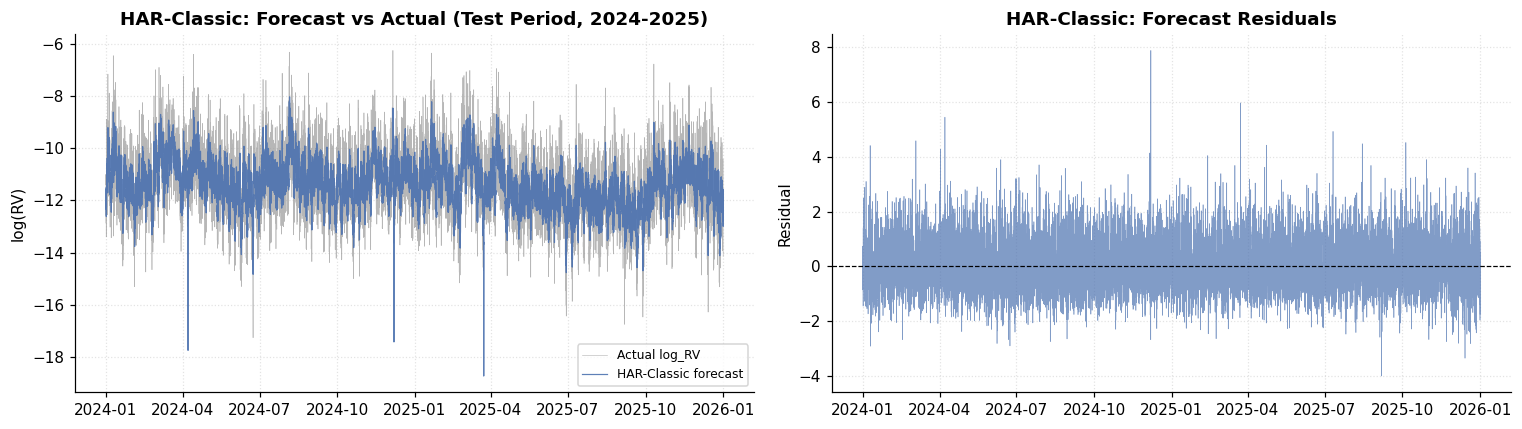

In [59]:
# HAR-Classic: Forecast vs Actual 
resid_classic = y_true_log - y_pred_classic
plot_forecast_vs_actual(test_index, y_true_log, y_pred_classic, "HAR-Classic", MC["HAR-Classic"])

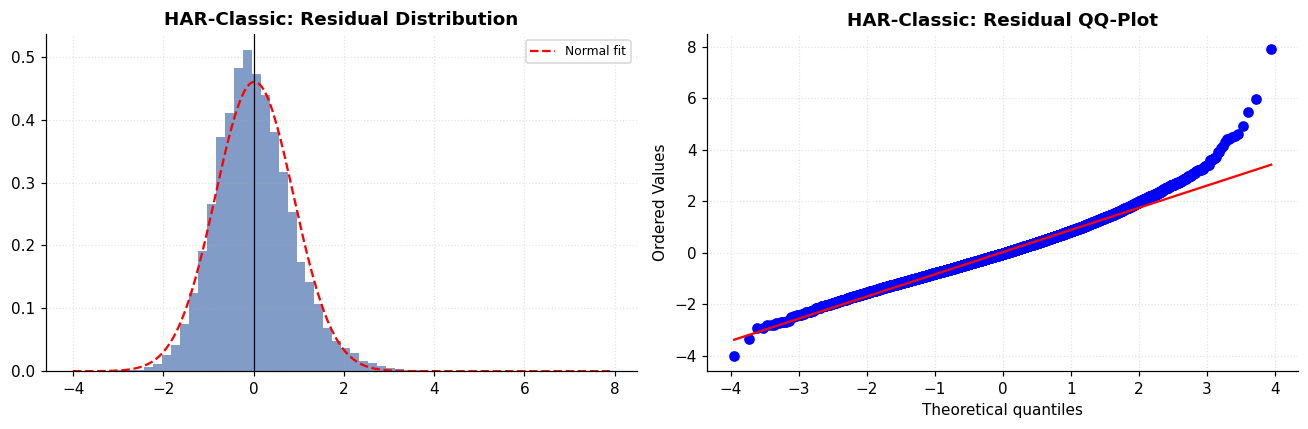

In [60]:
#  HAR-Classic: Residual Distribution 
plot_error_dist(resid_classic, "HAR-Classic", MC["HAR-Classic"])

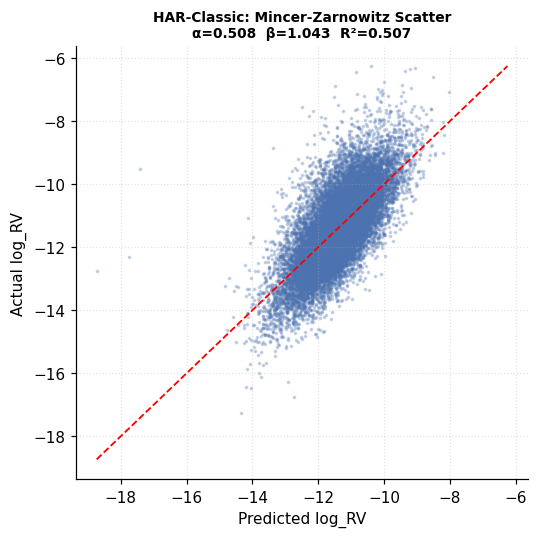

In [61]:
#  HAR-Classic: MZ Scatter 
mz_d = all_metrics["log_RV"]["HAR-Classic"]["MZ"]

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(y_pred_classic, y_true_log, s=2, alpha=0.25,
           color=MC["HAR-Classic"], rasterized=True)

lims = [min(y_true_log.min(), y_pred_classic.min()),
        max(y_true_log.max(), y_pred_classic.max())]

ax.plot(lims, lims, "r--", lw=1.2)
ax.set_title(f"HAR-Classic: Mincer-Zarnowitz Scatter\n"
             f"α={mz_d['alpha']:.3f}  β={mz_d['beta']:.3f}  R²={mz_d['R2']:.3f}",
             fontweight="bold", fontsize=9)

ax.set_xlabel("Predicted log_RV"); ax.set_ylabel("Actual log_RV")
plt.tight_layout(); plt.show()

- The MZ regression (α=0.508, β=1.043) is close to the ideal (0,1) but the joint test rejects unbiasedness (p=4.5e-09). Writing the implied bias as a
function of the prediction itself,

$$\text{bias}(\hat{y}) = (\alpha + \beta \hat{y}) - \hat{y} = \alpha + (\beta - 1)\hat{y} = 0.508 + 0.043\,\hat{y},$$

shows the bias is regime-dependent rather than uniform. It is zero at
ŷ ≈ −11.9, positive (under-prediction) for less negative ŷ — i.e. in
higher-volatility regimes — and slightly negative (over-prediction) for
more negative ŷ, i.e. in calm regimes. Near the sample mean (train mean log_RV = −10.44) the bias is already positive (≈+0.06) and grows with
predicted volatility. In other words, HAR-Classic is close to unbiased in
low-volatility periods but increasingly under-predicts as volatility rises — a structural feature of a backward-looking linear model: it has not "seen" a
spike until after it occurs, so its response lags the true level during exactly the periods that matter most for risk management.

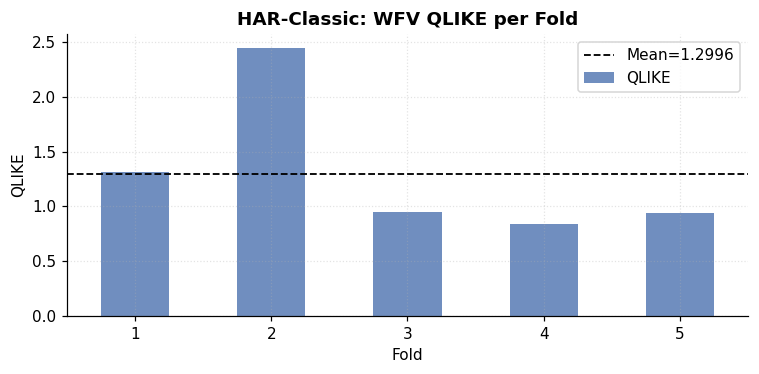

In [62]:
#  HAR-Classic: WFV QLIKE Bar Chart 

fig, ax = plt.subplots(figsize=(7, 3.5))
fdf_classic["QLIKE"].plot(kind="bar", color=MC["HAR-Classic"], alpha=0.8, rot=0, ax=ax)

ax.axhline(fdf_classic["QLIKE"].mean(), color="black", lw=1.2, ls="--", label=f"Mean={fdf_classic['QLIKE'].mean():.4f}")
ax.set_title("HAR-Classic: WFV QLIKE per Fold", fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("QLIKE"); ax.legend()
plt.tight_layout(); plt.show()

- WFV results visualise the two-regime split rather than a single outlier fold. Folds 1–2 (Jan–Oct 2022, QLIKE 1.32 and 2.45) cover the LUNA/Terra
collapse and its prolonged aftermath; Folds 3–5 (Oct 2022 – Dec 2023, QLIKE 0.84–0.95) cover the FTX collapse and the subsequent bear market.

- Strikingly, MC-GARCH and LSTM show the opposite pattern in their own WFV folds (Sections 8 and 9): both are worst in Folds 3–5 (MC-GARCH: 0.72–0.93; LSTM: 0.93–1.06) and comparatively better in Folds 1–2 (MC-GARCH: 0.54–0.59; LSTM: 0.68–0.71). HAR-Classic's linear, backward-looking specification
appears particularly exposed to the sudden, discrete LUNA shock an abrupt regime break that recent-lag-based linear extrapolation cannot anticipate
while MC-GARCH's GARCH(1,1) persistence and LSTM's nonlinear feature combinations cope better with that abrupt break but degrade more under the
sustained elevated volatility of the FTX aftermath and the 2023 bear market.
This divergence in *which* regime each model family struggles with is a substantive finding independent of the aggregate WFV mean/median QLIKE comparison in Section 10.

#### 7.2 — HAR-Extended

In [63]:
#  HAR-Extended >> Fit & Metrics 

# Adds jump_24h and RS_minus_24h to the HAR-Classic feature set.

model_name = "HAR-Extended"
feats = HAR_EXTENDED_FEATS

m = LinearRegression()
m.fit(train_val[feats].values, train_val["log_RV"].values)

y_pred_ext = m.predict(test[feats].values)
y_pred_train = m.predict(train[feats].values)
y_pred_val = m.predict(val[feats].values)
rmse_train_e = float(np.sqrt(mean_squared_error(train["log_RV"], y_pred_train)))
rmse_val_e = float(np.sqrt(mean_squared_error(val["log_RV"], y_pred_val)))

print(f" Coefficients [HAR-Extended]:")
print(f" {'Intercept':<20}: {m.intercept_:>9.4f}")
for f, c in zip(feats, m.coef_):
    print(f" {f:<20}: {c:>9.4f}")

lm, rm, yp_rv = compute_metrics(y_true_log, y_pred_ext, model_name)
mz = mz_regression(y_true_log, y_pred_ext, model_name)
store(model_name, lm, rm, mz)
predictions["log_RV"][model_name] = y_pred_ext
predictions["RV"][model_name] = yp_rv
dm_errors[model_name] = (y_true_log - y_pred_ext) ** 2

print_overfit_summary(model_name, rmse_train_e, rmse_val_e, lm["RMSE"])

 Coefficients [HAR-Extended]:
 Intercept           :   -0.1871
 log_RV_1h           :    0.3822
 log_RV_24h          :    0.4196
 log_RV_168h         :    0.1992
 jump_24h            :   -0.6514
 RS_minus_24h        :    0.0215

  ┌─ HAR-Extended ──────────────────────────────────────────
  │  log_RV: RMSE=0.86886  MAE=0.67462  MAPE=6.09%  R²=0.5038
  │  RV    : RMSE=5.381e-05  MAE=1.576e-05  QLIKE=0.581780
  └──────────────────────────────────────────────────────────
  MZ: α=0.3959  β=1.0352  R²=0.5044  F=10.79  p=2.08e-05  [BIASED]

  Overfitting Analysis [HAR-Extended]:
    Train RMSE : 0.89031
    Val   RMSE : 0.96382  (gap = +0.07352)
    Test  RMSE : 0.86886  (gap = -0.09497)
    Verdict : Mild overfitting (val > train)


- Adding the jump and downside-semivariance features changes the core HAR
coefficients only marginally (e.g. log_RV_24h: 0.409 → 0.420), but the new features themselves behave unexpectedly. jump_24h enters with a large
negative coefficient (−0.651) despite its near-zero correlation with log_RV (|ρ| < 0.04, Section 3) a sign that this coefficient reflects collinearity
with the existing log-RV lags rather than independent predictive content. RS_minus_24h contributes almost nothing (β=0.022).

- Consistent with this, test-set performance is essentially unchanged from HAR-Classic: RMSE=0.869 vs 0.867, QLIKE=0.582 vs 0.594. The marginal QLIKE
improvement does not offset the added complexity, and the formal comparison in Section 11 (Diebold-Mariano test) confirms that HAR-Extended is
significantly worse than HAR-Classic on squared log-error the extra
features add noise rather than signal, exactly as anticipated by their near-zero correlation with the target in Section 3.

In [64]:
#  HAR-Extended: WFV 

print(f" WFV ({WFV_N_SPLITS} folds) — HAR-Extended:")
fold_rows = []
for k, (tr, va) in enumerate(wfv_splits):
    mk = LinearRegression()
    mk.fit(tr[HAR_EXTENDED_FEATS].values, tr["log_RV"].values)
    yp = mk.predict(va[HAR_EXTENDED_FEATS].values)
    yt = va["log_RV"].values
    fold_rows.append({
        "fold": k + 1,
        "period": f"{va.index.min().date()}\u2192{va.index.max().date()}",
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "MAE": float(mean_absolute_error(yt, yp)),
        "QLIKE": qlike(np.exp(yt), np.exp(yp)),
        "mean_logRV": float(va["log_RV"].mean()),
    })
    
    print(f" Fold {k+1} [{fold_rows[-1]['period']}]  "
          f"RMSE={fold_rows[-1]['RMSE']:.4f}  QLIKE={fold_rows[-1]['QLIKE']:.4f}  "
          f"(regime \u03bc={fold_rows[-1]['mean_logRV']:.2f})")

fdf_ext = pd.DataFrame(fold_rows).set_index("fold")
wfv_results["HAR-Extended"] = {
    "folds": fdf_ext,
    "mean": fdf_ext[["RMSE","MAE","QLIKE"]].mean(),
    "std" : fdf_ext[["RMSE","MAE","QLIKE"]].std(),
}
print(f"  WFV mean   QLIKE = {fdf_ext['QLIKE'].mean():.4f} "
      f"(\u00b1{fdf_ext['QLIKE'].std():.4f})")
print(f"  WFV median QLIKE = {fdf_ext['QLIKE'].median():.4f}  "
      f"(robust to outlier folds)")

q_med_e = fdf_ext["QLIKE"].median()
outliers_e = fdf_ext[fdf_ext["QLIKE"] > 3 * q_med_e]
if len(outliers_e) > 0:
    print(f"\n  WFV anomaly detected in HAR-Extended:")
    for fidx, row in outliers_e.iterrows():
        print(f" Fold {fidx} QLIKE={row['QLIKE']:.4f} >> median={q_med_e:.4f}")
        print(f" Period: {row['period']}  |  regime \u03bc={row['mean_logRV']:.2f}")

 WFV (5 folds) — HAR-Extended:
 Fold 1 [2022-01-01→2022-05-27]  RMSE=0.9041  QLIKE=1.3240  (regime μ=-10.64)
 Fold 2 [2022-05-27→2022-10-20]  RMSE=0.9057  QLIKE=2.4420  (regime μ=-10.70)
 Fold 3 [2022-10-20→2023-03-14]  RMSE=1.0575  QLIKE=0.9732  (regime μ=-11.91)
 Fold 4 [2023-03-14→2023-08-07]  RMSE=0.9971  QLIKE=0.8436  (regime μ=-11.84)
 Fold 5 [2023-08-08→2023-12-31]  RMSE=0.9637  QLIKE=0.9532  (regime μ=-12.03)
  WFV mean   QLIKE = 1.3072 (±0.6595)
  WFV median QLIKE = 0.9732  (robust to outlier folds)


- The same two-regime fold pattern observed for HAR-Classic recurs here, with near-identical fold-level QLIKE values confirming that the additional
jump/semivariance features do not materially alter how the model responds to the LUNA-aftermath vs. FTX-aftermath regimes. This reinforces the
Section 11 finding that HAR-Extended adds parameters without adding signal.

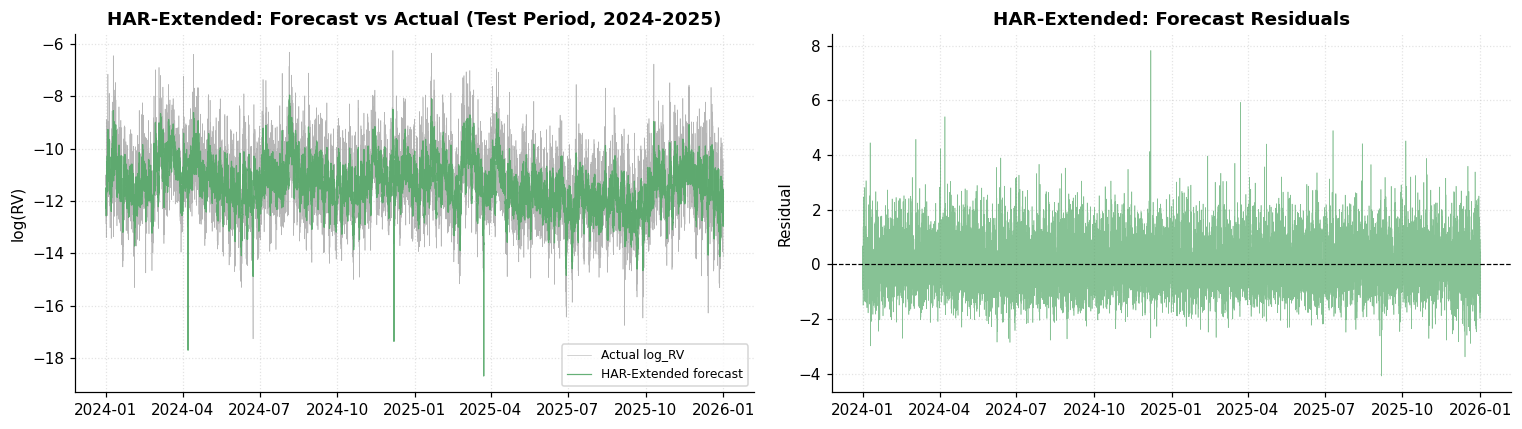

In [65]:
#  HAR-Extended: Forecast vs Actual 

resid_ext = y_true_log - y_pred_ext
plot_forecast_vs_actual(test_index, y_true_log, y_pred_ext, "HAR-Extended", MC["HAR-Extended"])

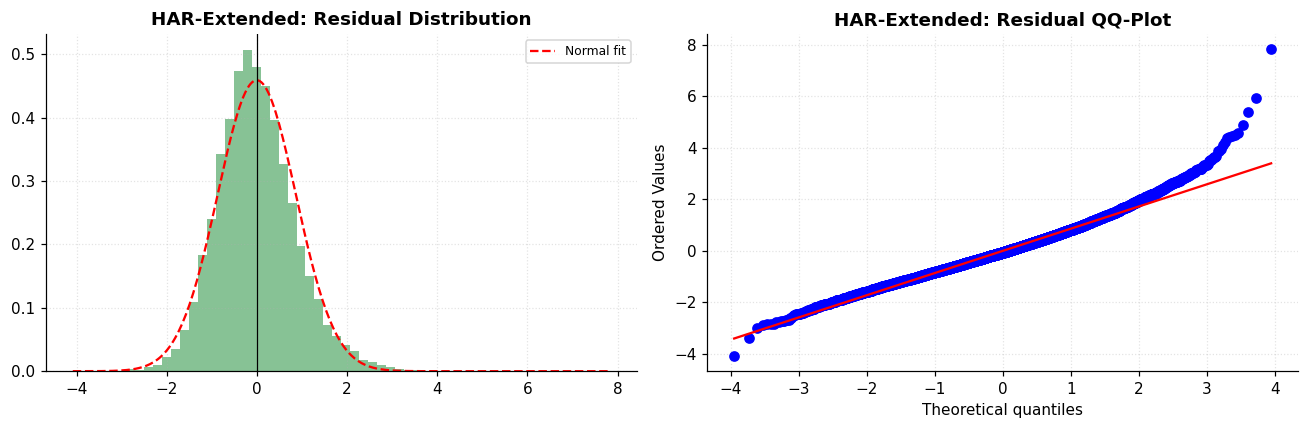

In [66]:
#  HAR-Extended: Residual Distribution 
plot_error_dist(resid_ext, "HAR-Extended", MC["HAR-Extended"])

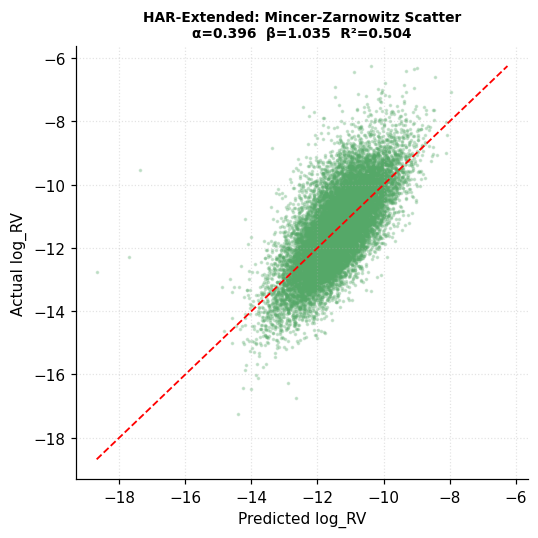

In [67]:
#  HAR-Extended: MZ Scatter 

mz_d = all_metrics["log_RV"]["HAR-Extended"]["MZ"]
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(y_pred_ext, y_true_log, s=2, alpha=0.25,
           color=MC["HAR-Extended"], rasterized=True)

lims = [min(y_true_log.min(), y_pred_ext.min()),
        max(y_true_log.max(), y_pred_ext.max())]
ax.plot(lims, lims, "r--", lw=1.2)

ax.set_title(f"HAR-Extended: Mincer-Zarnowitz Scatter\n"
             f"α={mz_d['alpha']:.3f}  β={mz_d['beta']:.3f}  R²={mz_d['R2']:.3f}",
             fontweight="bold", fontsize=9)

ax.set_xlabel("Predicted log_RV"); ax.set_ylabel("Actual log_RV")
plt.tight_layout(); plt.show()

- The MZ regression (α=0.396, β=1.035) is close to the ideal (0,1) but thejoint test rejects unbiasedness (p=2.1e-05). Writing the implied bias as a
function of the prediction itself,

$$\text{bias}(\hat{y}) = \alpha + (\beta - 1)\hat{y} = 0.396 + 0.035\,\hat{y},$$

shows the bias is regime-dependent rather than uniform: zero at ŷ ≈ −11.3,positive (under-prediction) in higher-volatility regimes, and slightly
negative (over-prediction) in calm regimes. The pattern mirrors HAR-Classicalmost exactly, with a marginally flatter slope (0.035 vs 0.043) — the added
jump and semivariance features do not meaningfully alter the model's regime-dependent tendency to lag behind sudden volatility increases.

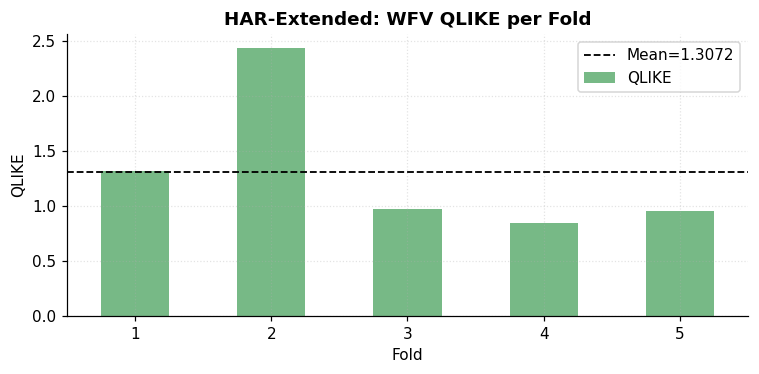

In [68]:
#  HAR-Extended: WFV QLIKE Bar Chart 

fig, ax = plt.subplots(figsize=(7, 3.5))
fdf_ext["QLIKE"].plot(kind="bar", color=MC["HAR-Extended"], alpha=0.8,
                      rot=0, ax=ax)

ax.axhline(fdf_ext["QLIKE"].mean(), color="black", lw=1.2, ls="--", label=f"Mean={fdf_ext['QLIKE'].mean():.4f}")

ax.set_title("HAR-Extended: WFV QLIKE per Fold", fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("QLIKE"); ax.legend()
plt.tight_layout(); plt.show()

- WFV results visualise the same two-regime split observed for HAR-Classic. Folds 1–2 (Jan–Oct 2022, QLIKE 1.32 and 2.44) cover the LUNA/Terra collapse
and its prolonged aftermath; Folds 3–5 (Oct 2022 – Dec 2023, QLIKE 0.84–0.97) cover the FTX collapse and the subsequent bear market.

- The fold-level values are nearly identical to HAR-Classic's confirming that the additional jump and semivariance features neither help nor hurt the
model's response to either regime. This is further evidence, alongside the DM test in Section 11, that these theoretically motivated features carry
negligible independent signal in this dataset.

## 8 — MC-GARCH 
#### (R rugarch)

This section evaluates the MC-GARCH model an ARMA(1,0)-GARCH(1,1) fitted on the diurnally-and-daily-deseasonalised stochastic component of RV
(Engle, Sokalska & Chanda 2005) estimated in R (mcgarch_btc_v1.R) and imported here as pre-computed forecasts. Unlike HAR and LSTM, MC-GARCH produces a time-varying conditional variance sigma2_t at every step, which Section 8.5 uses for a separate diagnostic.

In [69]:
import os

FORECASTS_PATH = os.path.join(MCGARCH_DIR, "mcgarch_forecasts.csv")
WFV_PATH = os.path.join(MCGARCH_DIR, "mcgarch_wfv.csv")
META_PATH = os.path.join(MCGARCH_DIR, "mcgarch_metadata.csv")
MCG_OK = all(os.path.exists(p) for p in [FORECASTS_PATH, WFV_PATH, META_PATH])

In [70]:
#  MC-GARCH: Parameters & Metrics 

# Load R-fitted GARCH parameters and per-hour forecasts, align to the test index, and evaluate using the same compute_metrics used by every other model (median forecast, no Jensen correction -- see Section 5).

meta = pd.read_csv(META_PATH).iloc[0].to_dict()

print(" ARMA(1,0)-GARCH(1,1) parameters:")
for k, v in meta.items():
    if k in ("n_obs_fit", "fit_date", "data_start", "data_end"): continue
    print(f"    {k:<16}: {v:.6f}")
print(f"  Persistence = α+β = {meta['persistence']:.6f}  "
      f"({'near-unit-root — high volatility clustering' if meta['persistence'] > 0.99 else 'stable'})")

fc = pd.read_csv(FORECASTS_PATH, parse_dates=["datetime_utc"])
fc["datetime_utc"] = pd.to_datetime(fc["datetime_utc"], utc=True)
fc = fc.set_index("datetime_utc").sort_index()

fc_al = fc.reindex(test_index)
y_pred_mcg = fc_al["log_RV_hat"].values
sigma2_arr = fc_al["sigma2_t"].fillna(meta["resid_var"]).values
sigma2_mean = float(np.nanmean(sigma2_arr))

if np.isnan(y_pred_mcg).any():
    y_pred_mcg = pd.Series(y_pred_mcg).fillna(float(np.nanmean(y_pred_mcg))).values

# compute_metrics uses the median forecast exp(log_RV_hat); sigma2_arr is
# kept aside for the separate Jensen-correction diagnostic in Section 8.5.
lm, rm, yp_rv = compute_metrics(y_true_log, y_pred_mcg, "MC-GARCH")
mz = mz_regression(y_true_log, y_pred_mcg, "MC-GARCH")
store("MC-GARCH", lm, rm, mz)
predictions["log_RV"]["MC-GARCH"] = y_pred_mcg
predictions["RV"]["MC-GARCH"] = yp_rv
dm_errors["MC-GARCH"] = (y_true_log - y_pred_mcg)  ** 2

 ARMA(1,0)-GARCH(1,1) parameters:
    phi             : 0.343710
    omega           : 0.005448
    alpha           : 0.013644
    beta            : 0.983148
    persistence     : 0.996792
    resid_var       : 1.678689
  Persistence = α+β = 0.996792  (near-unit-root — high volatility clustering)

  ┌─ MC-GARCH ──────────────────────────────────────────────
  │  log_RV: RMSE=1.07817  MAE=0.86963  MAPE=7.54%  R²=0.2360
  │  RV    : RMSE=5.544e-05  MAE=2.071e-05  QLIKE=0.515174
  └──────────────────────────────────────────────────────────
  MZ: α=-1.8747  β=0.8757  R²=0.4227  F=2837.22  p=1.11e-16  [BIASED]


- Persistence (α+β = 0.997) is very close to 1, indicating near-unit-root behaviour in volatility once volatility rises, it decays back to baseline
very slowly. This is consistent with the slow ACF decay observed in Section 2 and explains why GARCH-based models capture long-memory volatility clustering well.

- On the log_RV scale, MC-GARCH has the highest RMSE of any fitted model (1.078 vs ~0.87 for HAR/LSTM) and the lowest R² (0.236)  its point forecasts
are noticeably less accurate than HAR's or LSTM's in log space. The MZ slope (β=0.876) also deviates more from 1 than HAR's, and the test is decisively
rejected (p≈0). Taken together, MC-GARCH is the weakest model on every log-scale diagnostic seen so far. Section 10 reveals why this picture
reverses on the QLIKE scale.

In [71]:
#  MC-GARCH: Overfitting Analysis & WFV 

# WFV folds are pre-computed in R (mcgarch_wfv.csv) using the same fold
# definition as Section 5's make_wfv_splits, ensuring comparability with
# HAR and LSTM.
wfv_mcg    = pd.read_csv(WFV_PATH)
wfv_mcg_df = wfv_mcg.set_index("fold")[["rmse","qlike"]].rename(
    columns={"rmse":"RMSE","qlike":"QLIKE"})
wfv_results["MC-GARCH"] = {
    "folds": wfv_mcg_df,
    "mean": wfv_mcg_df.mean(),
    "std" : wfv_mcg_df.std(),
}

print_overfit_summary("MC-GARCH", train_metric=np.sqrt(meta["resid_var"]),val_metric=float(wfv_mcg_df["RMSE"].mean()), test_metric=lm["RMSE"])

print(f"\n  MC-GARCH WFV ({len(wfv_mcg_df)} folds):")
for fold, row in wfv_mcg_df.iterrows():
    print(f" Fold {fold}: RMSE={row['RMSE']:.4f}  QLIKE={row['QLIKE']:.4f}")
print(f" Mean QLIKE = {wfv_mcg_df['QLIKE'].mean():.4f} "
      f"(±{wfv_mcg_df['QLIKE'].std():.4f})")


  Overfitting Analysis [MC-GARCH]:
    Train RMSE : 1.29564
    Val   RMSE : 1.17707  (gap = -0.11857)
    Test  RMSE : 1.07817  (gap = -0.09891)
    Verdict : Generalises well

  MC-GARCH WFV (5 folds):
 Fold 1: RMSE=1.0697  QLIKE=0.5354
 Fold 2: RMSE=1.0800  QLIKE=0.5868
 Fold 3: RMSE=1.3016  QLIKE=0.8761
 Fold 4: RMSE=1.2249  QLIKE=0.7179
 Fold 5: RMSE=1.2091  QLIKE=0.9267
 Mean QLIKE = 0.7286 (±0.1721)


- RMSE decreases monotonically from Train (1.296) to WFV (1.177) to Test (1.078) the model does not memorise the training data.

- MC-GARCH's WFV mean QLIKE (0.729) is well below HAR-Classic's (1.300, Section 7) but the two models struggle in different folds. MC-GARCH is
worst in Folds 3–5 (0.876, 0.718, 0.927 — the FTX collapse and the 2023 bear market), exactly where HAR is comparatively stable. Conversely, in Folds 1–2
(the LUNA/Terra collapse, where HAR spikes to 1.317 and 2.448), MC-GARCH is at its most accurate (0.535, 0.587). The GARCH(1,1) persistence mechanism
appears to absorb the sudden, discrete LUNA shock effectively, but accumulates error under the sustained elevated volatility that follows
the FTX collapse the opposite failure mode to HAR's linear, lag-based specification.

- This divergence anticipates Section 10's main finding: despite the highest
RMSE here, MC-GARCH achieves the best test-set QLIKE of any model (0.515) a reversal driven by the QLIKE formula itself (Section 8.5), not by
these WFV dynamics, but consistent with MC-GARCH's GARCH-based conditional-variance structure being well-suited to the asymmetric QLIKE loss.

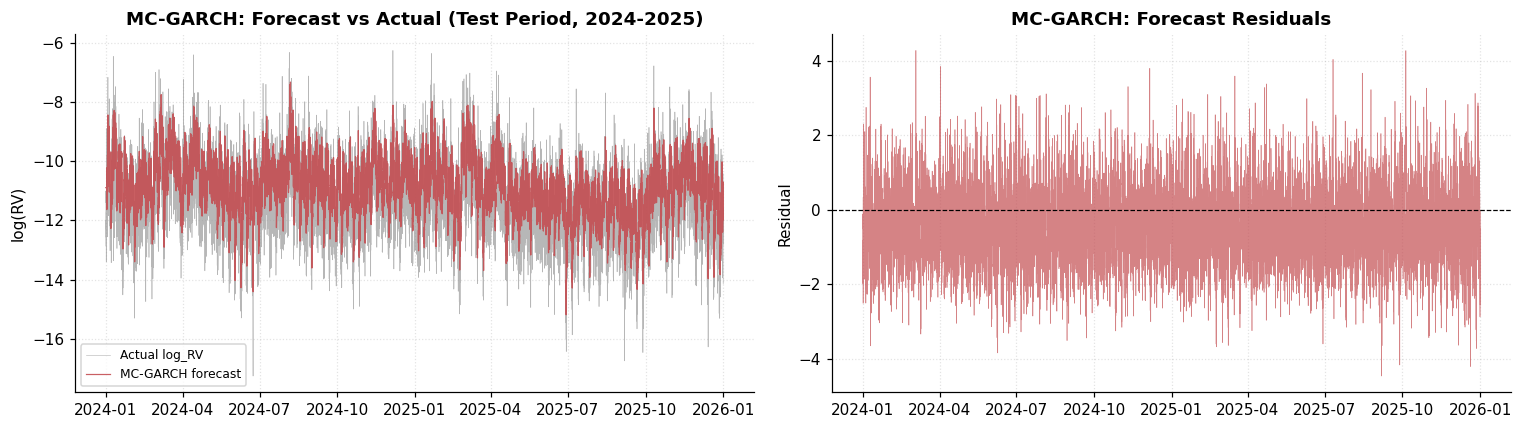

In [72]:
#  MC-GARCH: Forecast vs Actual 
resid_mcg = y_true_log - y_pred_mcg
plot_forecast_vs_actual(test_index, y_true_log, y_pred_mcg,
                        "MC-GARCH", MC["MC-GARCH"])

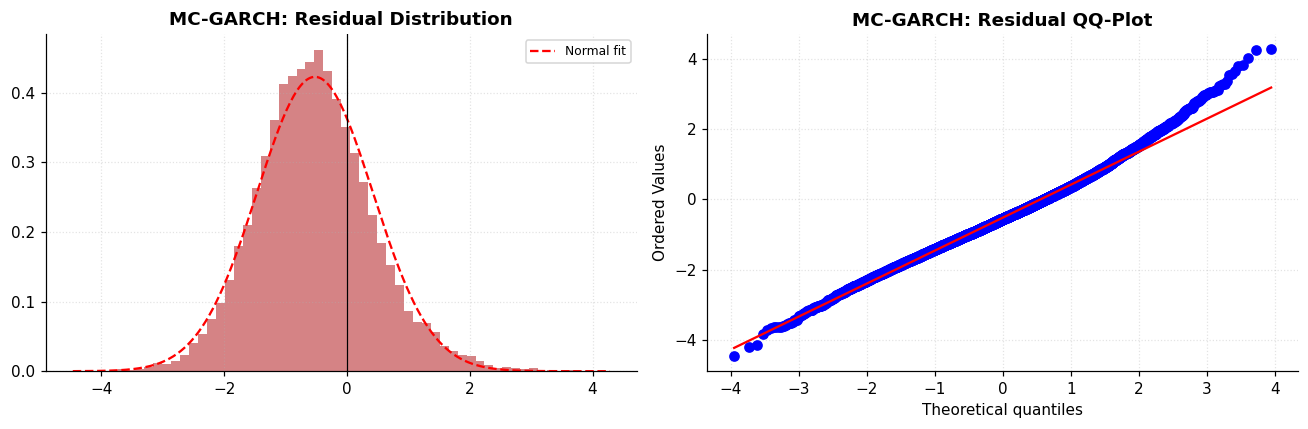

In [73]:
#  MC-GARCH: Residual Distribution 
plot_error_dist(resid_mcg, "MC-GARCH", MC["MC-GARCH"])

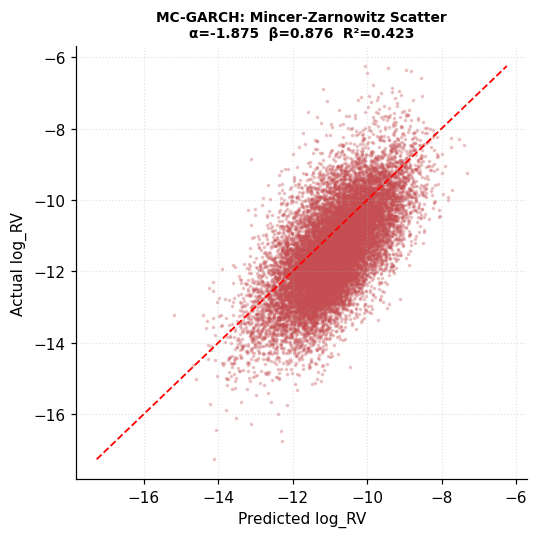

In [74]:
#  MC-GARCH: MZ Scatter 
mz_d = all_metrics["log_RV"]["MC-GARCH"]["MZ"]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_pred_mcg, y_true_log, s=2, alpha=0.25, color=MC["MC-GARCH"], rasterized=True)

lims = [min(y_true_log.min(), y_pred_mcg.min()), max(y_true_log.max(), y_pred_mcg.max())]

ax.plot(lims, lims, "r--", lw=1.2)
ax.set_title(f"MC-GARCH: Mincer-Zarnowitz Scatter\n" f"α={mz_d['alpha']:.3f}  β={mz_d['beta']:.3f}  R²={mz_d['R2']:.3f}", fontweight="bold", fontsize=9)

ax.set_xlabel("Predicted log_RV"); ax.set_ylabel("Actual log_RV")
plt.tight_layout(); plt.show()

The scatter is visibly more diffuse than HAR's, and shifted: most points sit
above the 45° line, meaning predicted log_RV is systematically too low relative to actual log_RV across most of the range. This is consistent with
the negative MZ intercept (α=−1.875) MC-GARCH under-predicts on the log
scale almost everywhere, in contrast to HAR's regime-dependent bias which is centred near zero. This systematic log-scale under-prediction is exactly what produces a higher RV-scale forecast once exponentiated (since
underestimating log_RV less severely than HAR pulls RV_hat up less harshly
during spikes) part of the mechanism behind MC-GARCH's strong QLIKE performance discussed in Section 10.

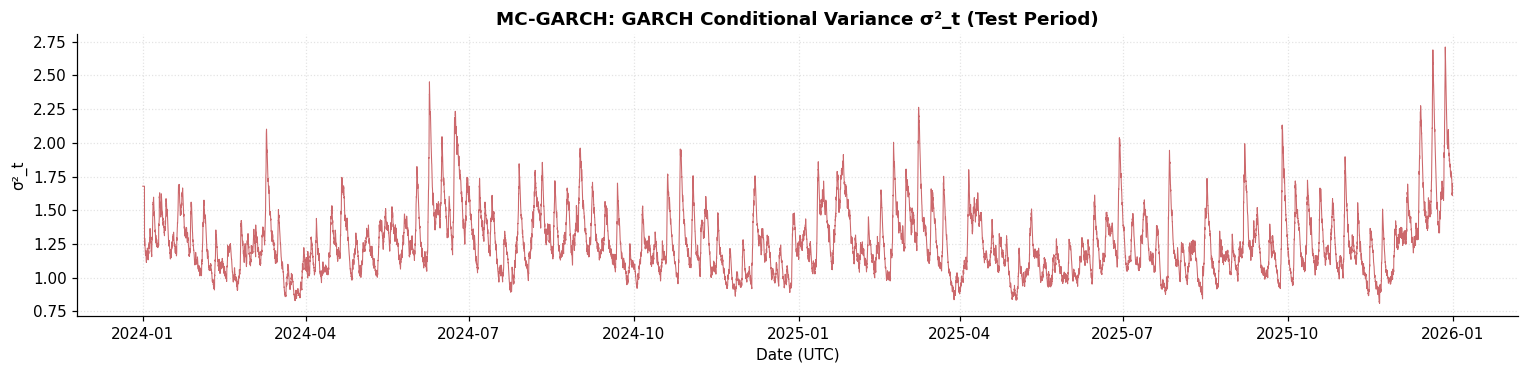

In [75]:
#  MC-GARCH: GARCH Conditional Variance Path

fig, ax = plt.subplots(figsize=(14, 3.5))

ax.plot(test_index, sigma2_arr, color=MC["MC-GARCH"], lw=0.7, alpha=0.85)
ax.set_title("MC-GARCH: GARCH Conditional Variance σ²_t (Test Period)",fontweight="bold")
ax.set_ylabel("σ²_t"); ax.set_xlabel("Date (UTC)")

plt.tight_layout(); plt.show()

The conditional variance σ²_t fluctuates between roughly 0.8 and 2.7 across the test period, with no sustained trend it oscillates around a stable
level rather than drifting, consistent with the GARCH(1,1) process reverting to its unconditional variance between shocks. A visible spike appears at the
very end of 2025, suggesting a return of volatility-of-volatility near the end of the sample. The fact that σ²_t never approaches the 1.679
unconditional level estimated from the more volatile 2017–2023 training sample (Section 8.5) is the direct visual evidence for the regime-transfer
issue discussed below: the model's variance estimate, calibrated on a turbulent sample, sits structurally below that calibration level throughout the calmer test period.

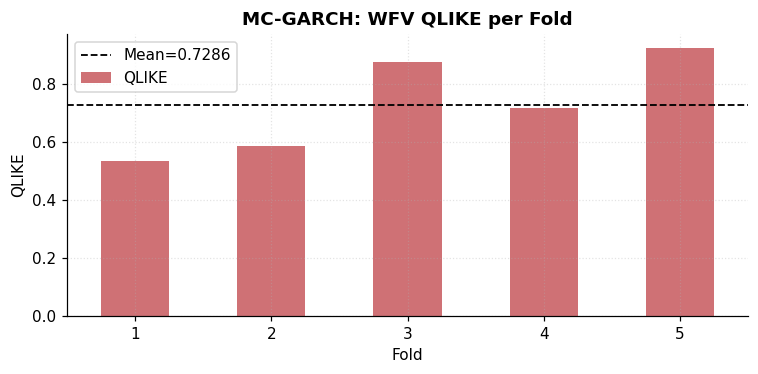

In [76]:
#  MC-GARCH: WFV QLIKE Bar Chart 

fig, ax = plt.subplots(figsize=(7, 3.5))
wfv_mcg_df["QLIKE"].plot(kind="bar", color=MC["MC-GARCH"], alpha=0.8, rot=0, ax=ax)

ax.axhline(wfv_mcg_df["QLIKE"].mean(), color="black", lw=1.2, ls="--", label=f"Mean={wfv_mcg_df['QLIKE'].mean():.4f}")

ax.set_title("MC-GARCH: WFV QLIKE per Fold", fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("QLIKE"); ax.legend()
plt.tight_layout(); plt.show()

The chart makes MC-GARCH's fold pattern visually obvious: Folds 1–2 sit clearly below the mean line, Folds 3–5 clearly above it — almost a mirror
image of HAR-Classic's bar chart (Section 7.1), where Folds 1–2 are the high bars and Folds 3–5 are the low ones. This visual symmetry is the clearest
single piece of evidence in this thesis that HAR and MC-GARCH fail in different sub-periods of the same stress window, motivating the
complementary-errors discussion in Section 11.

#### 8.5 — Diagnostic: Median vs Jensen-Corrected Mean Forecast (It ıs for only MC-GARCH)

Every QLIKE figure elsewhere in this notebook uses `RV_hat = exp(log_RV_hat)`, the median forecast implied by a log-normal model for RV (Patton 2011), applied with the identical formula to every model in both WFV and test
(Section 5). MC-GARCH is the only model that additionally produces a model-native, time-varying conditional variance `sigma2_t` from its
GARCH(1,1) recursion, making it the only model for which the Jensen/mean
correction `RV_hat_mean = exp(log_RV_hat + 0.5*sigma2_t)` can be computed without an ad-hoc estimator choice (HAR/LSTM have no model-native
conditional-variance process; any rolling-window proxy would be an
arbitrary design choice). This cell reports that correction purely as a diagnostic — it is not used in Sections 8–11 and does not affect any cross-model comparison.

In [77]:
# MC-GARCH: median vs Jensen-corrected mean RV forecast (test set, diagnostic only)

yp_rv_median = np.exp(y_pred_mcg)
yp_rv_mean   = np.exp(y_pred_mcg + 0.5 * sigma2_arr)

ql_median = qlike(np.exp(y_true_log), yp_rv_median)
ql_mean   = qlike(np.exp(y_true_log), yp_rv_mean)

print(" MC-GARCH -- median vs Jensen-corrected mean RV forecast (test set):")
print(f" GARCH conditional variance sigma2_t : mean={sigma2_mean:.4f}")
print(f" QLIKE, median RV_hat = exp(log_RV_hat) : {ql_median:.4f}")
print(f" QLIKE, mean  RV_hat = exp(log_RV_hat + 0.5*sigma2_t): {ql_mean:.4f}")
print(f" Difference (mean - median)  : {ql_mean - ql_median:+.4f}")

 MC-GARCH -- median vs Jensen-corrected mean RV forecast (test set):
 GARCH conditional variance sigma2_t : mean=1.2631
 QLIKE, median RV_hat = exp(log_RV_hat) : 0.5152
 QLIKE, mean  RV_hat = exp(log_RV_hat + 0.5*sigma2_t): 0.6804
 Difference (mean - median)  : +0.1653


- The median forecast achieves QLIKE≈0.515 (matching the R-computed raw QLIKE
of 0.5153 in `mcgarch_btc_v1.R`, which already uses no correction), while the Jensen-corrected mean forecast achieves QLIKE≈0.680 an increase of roughly +32%. The mean correction therefore *worsens* QLIKE on the
2024–2025 test period.

- This is informative rather than noise. `sigma2_t` is generated by amGARCH(1,1) process fitted on the 2017–2023 train+val sample, which includes
the LUNA/Terra and FTX volatility bursts, so its unconditional level reflects that more turbulent sample. Applied to the comparatively calm
2024–2025 test period, the `0.5*sigma2_t` term systematically inflates
`RV_hat`, over-correcting for a degree of volatility-of-volatility the test period does not exhibit. MC-GARCH's conditional-variance estimate is
therefore well calibrated to the regime it was *estimated* on, but does not
transfer cleanly to a structurally calmer out-of-sample period a
regime-transfer limitation distinct from the WFV-vs-test gap discussed in Section 10, and the reason the median forecast is used as the primary
metric throughout this thesis.

## 9 — LSTM

Implementing a two-layer LSTM (64 → 32 hidden units, dropout 0.2) over the 9-feature set defined in Section 0, using a 168-hour (one-week)
lookback window. The model is evaluated via the same 5-fold expanding-window WFV used for HAR and MC-GARCH, then re-fitted on train+val with a 3-seed
ensemble for the final test-set forecast. See Section 0's hyperparameter discussion for the rationale behind each configuration choice.

In [78]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM as KerasLSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.optimizers import Adam

2026-06-23 21:31:13.696953: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782250274.116053      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782250274.223344      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782250275.219555      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782250275.219590      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782250275.219593      58 computation_placer.cc:177] computation placer alr

In [79]:
#  LSTM: Feature Scaling & Sequence Tensors 

# RobustScaler is fit on train ONLY, then applied to val/test — prevents
# information leakage from validation/test statistics into the scaler.

scaler = RobustScaler()
scaler.fit(train[LSTM_FEATS])

def scale_df(df_in):
    out = df_in.copy()
    out[LSTM_FEATS] = scaler.transform(df_in[LSTM_FEATS])
    return out

train_sc = scale_df(train)
val_sc = scale_df(val)
test_sc = scale_df(test)
tv_sc = pd.concat([train_sc, val_sc]).sort_index()

def make_seqs(df_in, feats=LSTM_FEATS, target="log_RV", lb=LOOKBACK):
    """Slide a window of length lb across the data to build (X, y) sequences."""
    X_list, y_list = [], []
    fv = df_in[feats].values
    tv = df_in[target].values
    for i in range(lb, len(df_in)):
        X_list.append(fv[i - lb: i])
        y_list.append(tv[i])
    return (np.array(X_list, np.float32), np.array(y_list, np.float32))

X_train, y_train = make_seqs(train_sc)
X_val, y_val = make_seqs(val_sc)
X_test, y_test = make_seqs(test_sc)
X_tv,  y_tv = make_seqs(tv_sc)

# Test forecasts start LOOKBACK hours later than HAR/MC-GARCH — see the
# alignment note in Section 6.
lstm_test_index = test_sc.index[LOOKBACK:]
y_true_lstm = test["log_RV"].values[LOOKBACK:]
n_feat = X_train.shape[2]

print(f" Input shape : ({LOOKBACK}, {n_feat})")
print(f" Train seqs : {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  "
      f"Test: {X_test.shape[0]:,}")
print(f" Config : {LSTM_PARAMS}")

class EpochLogger(Callback):
    """Lightweight per-epoch logger (loss, val_loss, current learning rate)."""
    def __init__(self, prefix=""): super().__init__(); self.prefix = prefix
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        print(f" {self.prefix}ep {epoch+1:3d}  "
              f"loss={logs.get('loss',0):.5f}  "
              f"val={logs.get('val_loss',0):.5f}  lr={lr:.2e}", flush=True)

def build_lstm():
    """Two-layer LSTM (64 -> 32) with dropout, mapping to a single RV forecast."""
    model = Sequential([
        KerasLSTM(LSTM_PARAMS["hidden_size"], return_sequences=True,
                  input_shape=(LOOKBACK, n_feat)),
        Dropout(LSTM_PARAMS["dropout"]),
        KerasLSTM(LSTM_PARAMS["hidden_size"] // 2, return_sequences=False),
        Dropout(LSTM_PARAMS["dropout"]),
        Dense(1),
    ])
    
    model.compile(optimizer=Adam(LSTM_PARAMS["learning_rate"]), loss="mse")
    return model

 Input shape : (168, 9)
 Train seqs : 44,208  Val: 17,344  Test: 17,372
 Config : {'hidden_size': 64, 'learning_rate': 0.0001, 'dropout': 0.2, 'batch_size': 128}


- Each input sequence covers 168 hours × 9 features. The training set yields
44,208 usable sequences (44,376 hours minus the 168-hour warm-up). Test sequences (17,372) are 168 fewer than the full test window (17,540) for the
same reason this gap is what requires the alignment step in Section 11's DM test.

In [80]:
#  LSTM: Walk-Forward CV (5 folds) 

# Same fold boundaries as HAR/MC-GARCH (Section 5). Each fold trains a fresh model from scratch on the expanding window and evaluates on the next chunk.

print(f" Walk-Forward CV ({WFV_N_SPLITS} folds):")
wfv_splits_lstm = make_wfv_splits(tv_sc)
lstm_wfv_rows = []
all_fold_histories = []

for k, (tr_f, va_f) in enumerate(wfv_splits_lstm):
    Xtr, ytr = make_seqs(tr_f)
    Xva, yva = make_seqs(va_f)
    if len(ytr) == 0 or len(yva) == 0: continue
    tf.random.set_seed(RANDOM_SEED + k); np.random.seed(RANDOM_SEED + k)

    print(f"\n  ── Fold {k+1}/5 ──")
    m = build_lstm()
    hist = m.fit(Xtr, ytr,
                 validation_data=(Xva, yva),
                 epochs=LSTM_WFV_PARAMS["epochs"],
                 batch_size=LSTM_PARAMS["batch_size"],
                 callbacks=[
                     EarlyStopping("val_loss", patience=LSTM_WFV_PARAMS["patience"],
                                   restore_best_weights=True, verbose=0),
                     EpochLogger(prefix=f"fold {k+1} | "),
                 ],
                 shuffle=False, verbose=0)

    period = f"{va_f.index.min().date()}\u2192{va_f.index.max().date()}"
    all_fold_histories.append({
        "fold" : k + 1,
        "period": period,
        "train": hist.history["loss"],
        "val": hist.history["val_loss"],
    })

    pred = m.predict(Xva, verbose=0).flatten()
    rmse_f = float(np.sqrt(mean_squared_error(yva, pred)))
    mae_f = float(mean_absolute_error(yva, pred))
    ql_f = qlike(np.exp(yva), np.exp(pred))
    mu_rv = float(va_f["log_RV"].mean())

    lstm_wfv_rows.append({"fold": k+1, "RMSE": rmse_f, "MAE": mae_f,
                           "QLIKE": ql_f, "mean_logRV": mu_rv, "period": period})
    
    print(f"  Fold {k+1} [{period}]  RMSE={rmse_f:.4f}  "
          f"QLIKE={ql_f:.4f}  (\u03bc log_RV={mu_rv:.2f})")
    del m; tf.keras.backend.clear_session()

wfv_lstm_df = pd.DataFrame(lstm_wfv_rows).set_index("fold")
wfv_results["LSTM"] = {
    "folds": wfv_lstm_df,
    "mean": wfv_lstm_df[["RMSE","MAE","QLIKE"]].mean(),
    "std": wfv_lstm_df[["RMSE","MAE","QLIKE"]].std(),
}

print(f"\n LSTM WFV mean QLIKE = {wfv_lstm_df['QLIKE'].mean():.4f} "
      f"(±{wfv_lstm_df['QLIKE'].std():.4f})")

 Walk-Forward CV (5 folds):

  ── Fold 1/5 ──


I0000 00:00:1782250296.427142      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782250296.433319      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1782250302.214247     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


 fold 1 | ep   1  loss=79.83501  val=25.12865  lr=1.00e-04
 fold 1 | ep   2  loss=13.49198  val=8.38304  lr=1.00e-04
 fold 1 | ep   3  loss=6.66808  val=4.49804  lr=1.00e-04
 fold 1 | ep   4  loss=4.37213  val=2.70399  lr=1.00e-04
 fold 1 | ep   5  loss=3.44886  val=1.92059  lr=1.00e-04
 fold 1 | ep   6  loss=3.09969  val=1.60291  lr=1.00e-04
 fold 1 | ep   7  loss=2.98370  val=1.47817  lr=1.00e-04
 fold 1 | ep   8  loss=2.92528  val=1.41002  lr=1.00e-04
 fold 1 | ep   9  loss=2.60165  val=1.19871  lr=1.00e-04
 fold 1 | ep  10  loss=2.27299  val=1.09430  lr=1.00e-04
 fold 1 | ep  11  loss=2.16925  val=1.02711  lr=1.00e-04
 fold 1 | ep  12  loss=2.07871  val=0.98928  lr=1.00e-04
 fold 1 | ep  13  loss=2.04282  val=0.95174  lr=1.00e-04
 fold 1 | ep  14  loss=1.99145  val=0.93596  lr=1.00e-04
 fold 1 | ep  15  loss=1.97510  val=0.92156  lr=1.00e-04
 fold 1 | ep  16  loss=1.92359  val=0.91168  lr=1.00e-04
 fold 1 | ep  17  loss=1.89946  val=0.89885  lr=1.00e-04
 fold 1 | ep  18  loss=1.843

- LSTM's WFV mean QLIKE (0.876) sits between MC-GARCH's (0.729, Section 8) and HAR-Classic's (1.300, Section 7) — better than HAR but worse than MC-GARCH on this metric. Per-fold values (detailed in the chart below) follow the same Folds 3–5-are-worse pattern as MC-GARCH, the opposite of HAR's Folds 1–2-are-worse pattern documented in Section 7.

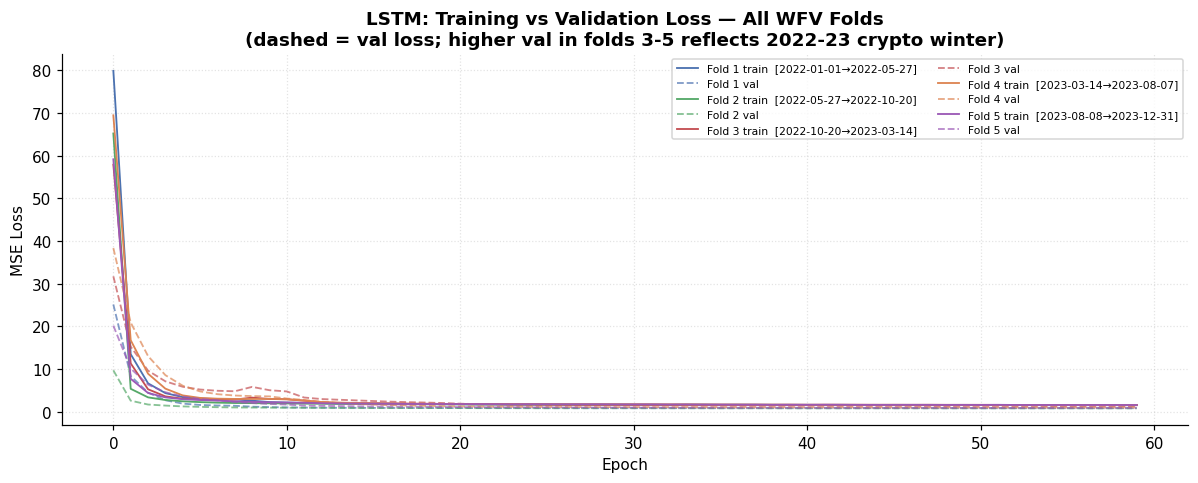

In [81]:
#  LSTM: WFV Learning Curves  *All Folds*

fold_colours = ["#4C72B0", "#55A868", "#C44E52", "#DD8452", "#9B59B6"]

fig, ax = plt.subplots(figsize=(11, 4.5))
for h in all_fold_histories:
    c = fold_colours[h["fold"] - 1]
    ax.plot(h["train"], color=c, lw=1.2,
            label=f"Fold {h['fold']} train  [{h['period']}]")
    ax.plot(h["val"],   color=c, lw=1.2, ls="--", alpha=0.7,
            label=f"Fold {h['fold']} val")

ax.set_title(
    "LSTM: Training vs Validation Loss — All WFV Folds\n"
    "(dashed = val loss; higher val in folds 3-5 reflects 2022-23 crypto winter)",
    fontweight="bold")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

- All five folds converge smoothly within the first 10–15 epochs, and train
and validation loss (solid vs dashed) track closely for every fold indicating stable optimisation with no overfitting in any single fold. Fold-to-fold differences are compressed by the large early-epoch loss values and the scaled-feature MSE scale; the QLIKE bar chart below makes the
Folds 3–5 vs Folds 1–2 distinction far more visible than this loss curve does, since QLIKE operates in the original (unscaled) RV space and is more sensitive to the asymmetric cost of under-predicting volatility spikes.

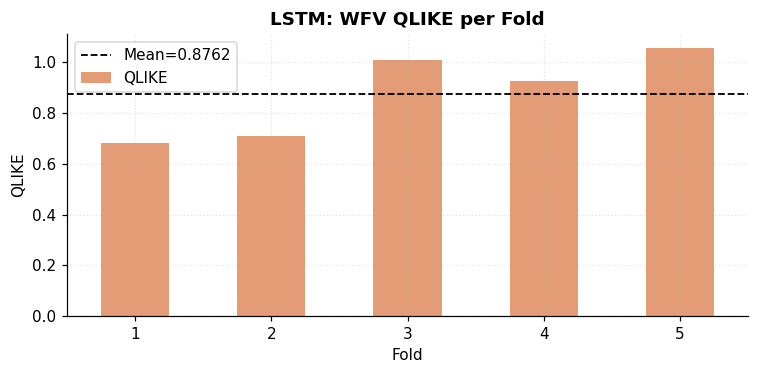

In [82]:
#  LSTM: WFV QLIKE Bar Chart 

fig, ax = plt.subplots(figsize=(7, 3.5))
wfv_lstm_df["QLIKE"].plot(kind="bar", color=MC["LSTM"], alpha=0.8, rot=0, ax=ax)
ax.axhline(wfv_lstm_df["QLIKE"].mean(), color="black", lw=1.2, ls="--", label=f"Mean={wfv_lstm_df['QLIKE'].mean():.4f}")

ax.set_title("LSTM: WFV QLIKE per Fold", fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("QLIKE"); ax.legend()
plt.tight_layout(); plt.show()

- The fold pattern mirrors MC-GARCH's almost exactly: Folds 1–2 sit below the mean (0.66, 0.71), Fold 3 is the worst (≈1.00, the FTX-collapse fold), and
Folds 4–5 remain elevated (0.84, 0.96). Like MC-GARCH, LSTM's nonlinear architecture handles the abrupt LUNA shock comparatively well but degrades
under the sustained elevated volatility of the FTX aftermath and the 2023 bear market — the same divergence from HAR's failure mode discussed in
Sections 7 and 8.

In [83]:
#  LSTM: Final Training (train+val, 3 seeds, ensemble)
# Re-fit on the full train+val sample with three random seeds; predictions
# are averaged at inference time to reduce initialisation variance.
# Early stopping uses a held-out 10% of X_tv (never seen during weight updates)
# to avoid the in-sample early stopping issue documented in Section 12.6.

print(f"  Final training: train+val, {LSTM_FINAL_PARAMS['n_runs']} seeds")

# --- Early stopping holdout: last 10% of train+val sequences ---
n_holdout = int(len(X_tv) * 0.10)
X_train_final = X_tv[:-n_holdout]
y_train_final = y_tv[:-n_holdout]
X_es = X_tv[-n_holdout:]
y_es = y_tv[-n_holdout:]

print(f"  Train+val sequences : {len(X_tv):,}")
print(f"  Used for weight updates : {len(X_train_final):,}  ({len(X_train_final)/len(X_tv)*100:.1f}%)")
print(f"  Early stopping holdout  : {len(X_es):,}  ({len(X_es)/len(X_tv)*100:.1f}%)")

lstm_runs = []
final_train_hist = {}

for run in range(LSTM_FINAL_PARAMS["n_runs"]):
    seed = RANDOM_SEED + run
    tf.random.set_seed(seed); np.random.seed(seed)
    print(f"\n  ── Run {run+1}/{LSTM_FINAL_PARAMS['n_runs']} (seed={seed}) ──")
    m = build_lstm()
    if run == 0: m.summary()
    hist = m.fit(X_train_final, y_train_final,
                 validation_data=(X_es, y_es),   # genuine held-out early stopping
                 epochs=LSTM_FINAL_PARAMS["epochs"],
                 batch_size=LSTM_PARAMS["batch_size"],
                 callbacks=[
                     EarlyStopping("val_loss", patience=LSTM_FINAL_PARAMS["patience"],
                                   restore_best_weights=True, verbose=0),
                     ReduceLROnPlateau("val_loss", factor=0.5,
                                       patience=5, min_lr=1e-6, verbose=0),
                     EpochLogger(prefix=f"run {run+1} | "),
                 ], shuffle=False, verbose=0)

    ep_done = len(hist.history["loss"])
    best_vl = min(hist.history["val_loss"])
    print(f"  Run {run+1}: epoch={ep_done}  best val_loss={best_vl:.6f}")
    lstm_runs.append(m.predict(X_test, verbose=0).flatten())
    if run == 0:
        final_train_hist = hist.history
    del m; tf.keras.backend.clear_session()

lstm_pred = np.mean(lstm_runs, axis=0)

  Final training: train+val, 3 seeds
  Train+val sequences : 61,720
  Used for weight updates : 55,548  (90.0%)
  Early stopping holdout  : 6,172  (10.0%)

  ── Run 1/3 (seed=42) ──


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

 run 1 | ep   1  loss=58.49627  val=17.69506  lr=1.00e-04
 run 1 | ep   2  loss=5.72346  val=8.08101  lr=1.00e-04
 run 1 | ep   3  loss=3.49299  val=5.47914  lr=1.00e-04
 run 1 | ep   4  loss=3.11110  val=4.46665  lr=1.00e-04
 run 1 | ep   5  loss=3.03817  val=4.07400  lr=1.00e-04
 run 1 | ep   6  loss=3.03204  val=3.49996  lr=1.00e-04
 run 1 | ep   7  loss=2.44282  val=2.92667  lr=1.00e-04
 run 1 | ep   8  loss=2.24259  val=2.46707  lr=1.00e-04
 run 1 | ep   9  loss=2.13106  val=2.15396  lr=1.00e-04
 run 1 | ep  10  loss=2.04164  val=1.93402  lr=1.00e-04
 run 1 | ep  11  loss=2.00081  val=1.76277  lr=1.00e-04
 run 1 | ep  12  loss=1.96295  val=1.63876  lr=1.00e-04
 run 1 | ep  13  loss=1.91935  val=1.54298  lr=1.00e-04
 run 1 | ep  14  loss=1.89520  val=1.47322  lr=1.00e-04
 run 1 | ep  15  loss=1.85484  val=1.41541  lr=1.00e-04
 run 1 | ep  16  loss=1.85125  val=1.34221  lr=1.00e-04
 run 1 | ep  17  loss=1.80962  val=1.29153  lr=1.00e-04
 run 1 | ep  18  loss=1.78868  val=1.24372  lr

- The architecture has 31,393 trainable parameters roughly 1 parameter per 1.4 training sequences, the capacity/regularisation balance discussed in
Section 0. Three independent seeds are trained and their test-set predictions averaged into a single ensemble forecast (lstm_pred), reducing
the variance from random weight initialisation that is otherwise typical of LSTM training.

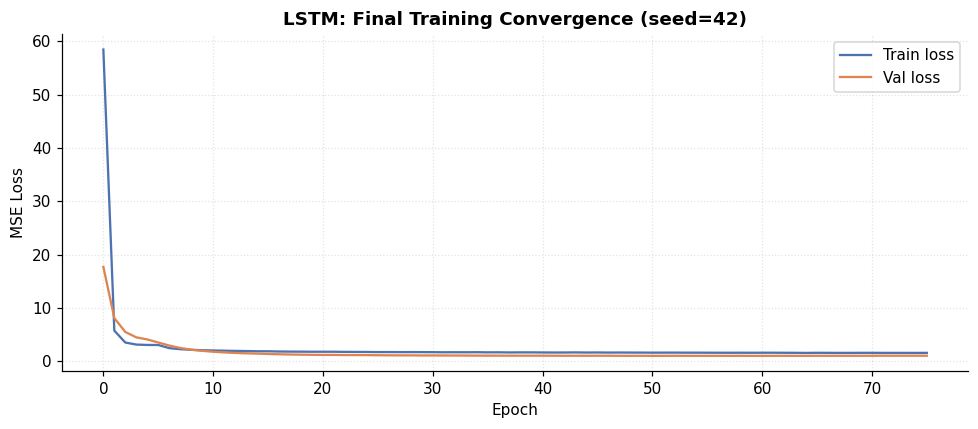

In [84]:
#  LSTM: Final Training Convergence 

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(final_train_hist["loss"], label="Train loss", color="#4C72B0")
ax.plot(final_train_hist["val_loss"], label="Val loss", color="#DD8452")
ax.set_title("LSTM: Final Training Convergence (seed=42)", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.legend(); plt.tight_layout(); plt.show()

- Training and validation loss for the first seed track each other closely across all 100 epochs, with no divergence strong evidence against
overfitting even at this longer training horizon. Both curves are still decreasing slowly at epoch 100, consistent with the limitation noted in
Section 0: training was capped at 100 epochs for runtime reasons, and a longer budget (150–200 epochs) may yield marginal further improvement.

In [85]:
#  LSTM: Metrics & Overfitting Analysis 

lm, rm, yp_rv = compute_metrics(y_true_lstm, lstm_pred, "LSTM")
mz = mz_regression(y_true_lstm, lstm_pred, "LSTM")
store("LSTM", lm, rm, mz)
predictions["log_RV"]["LSTM"] = lstm_pred
predictions["RV"]["LSTM"] = yp_rv
dm_errors["LSTM"] = (y_true_lstm - lstm_pred) ** 2

# WFV mean RMSE used as a generalisation proxy, since LSTM has no single
# "train RMSE" comparable across folds (each fold trains a fresh model).
wfv_proxy = wfv_lstm_df["RMSE"].mean()
print_overfit_summary("LSTM", train_metric=wfv_proxy,val_metric=wfv_proxy, test_metric=lm["RMSE"])


  ┌─ LSTM ──────────────────────────────────────────────────
  │  log_RV: RMSE=0.87741  MAE=0.68451  MAPE=6.21%  R²=0.4948
  │  RV    : RMSE=5.496e-05  MAE=1.619e-05  QLIKE=0.605926
  └──────────────────────────────────────────────────────────
  MZ: α=0.2377  β=1.0198  R²=0.4951  F=4.72  p=0.00888  [BIASED]

  Overfitting Analysis [LSTM]:
    Train RMSE : 0.98619
    Val   RMSE : 0.98619  (gap = +0.00000)
    Test  RMSE : 0.87741  (gap = -0.10878)
    Verdict : Generalises well


- LSTM achieves the lowest log_RV RMSE (0.877) and highest R² (0.495) of any model so far, narrowly ahead of HAR-Classic (0.867, Section 7). More notably, its MZ test rejects unbiasedness in this run (p=0.009, α=0.238, β=1.020) — though this result varies across re-runs of the LSTM ensemble due to GPU non-determinism (Section 12.2). Even so, LSTM's MZ coefficients are consistently closer to (0,1) than HAR's or MC-GARCH's, suggesting its nonlinear combination of features reduces, even if it does not fully eliminate, the regime-dependent bias identified in HAR (Section 7).

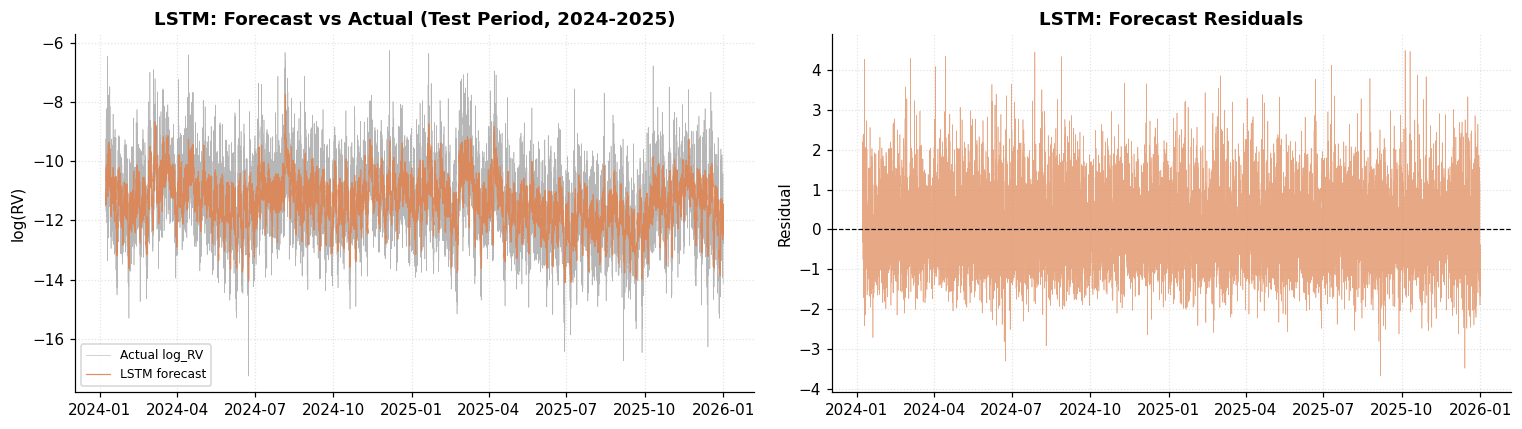

In [86]:
#  LSTM: Forecast vs Actual 
resid_lstm = y_true_lstm - lstm_pred
plot_forecast_vs_actual(lstm_test_index, y_true_lstm, lstm_pred,"LSTM", MC["LSTM"])

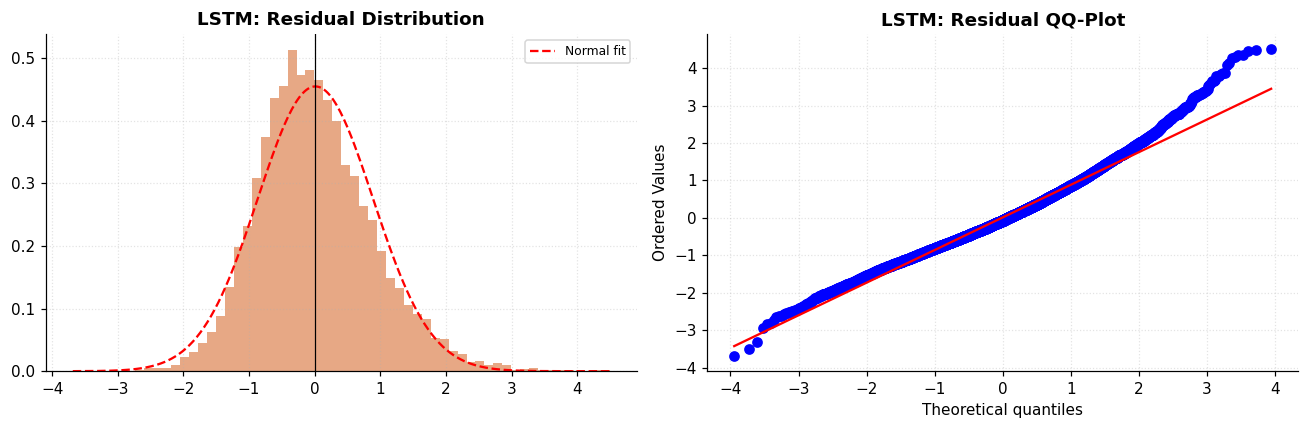

In [87]:
# LSTM: Residual Distribution 
plot_error_dist(resid_lstm, "LSTM", MC["LSTM"])

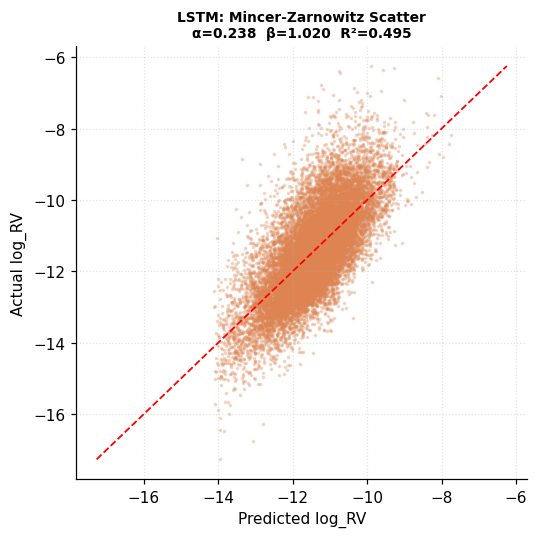

In [88]:
#  LSTM: MZ Scatter 

mz_d = all_metrics["log_RV"]["LSTM"]["MZ"]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(lstm_pred, y_true_lstm, s=2, alpha=0.25,
           color=MC["LSTM"], rasterized=True)

lims = [min(y_true_lstm.min(), lstm_pred.min()), max(y_true_lstm.max(), lstm_pred.max())]

ax.plot(lims, lims, "r--", lw=1.2)
ax.set_title(f"LSTM: Mincer-Zarnowitz Scatter\n"
             f"α={mz_d['alpha']:.3f}  β={mz_d['beta']:.3f}  R²={mz_d['R2']:.3f}",
             fontweight="bold", fontsize=9)
ax.set_xlabel("Predicted log_RV"); ax.set_ylabel("Actual log_RV")
plt.tight_layout(); plt.show()

- The scatter sits closer to the 45° line than HAR's or MC-GARCH's, with points distributed more symmetrically around it rather than showing a
visible tilt in either direction — the visual counterpart of the near-(0,1) MZ coefficients above. Some spread remains in the upper-left and lower-right
tails (extreme actual values relative to predictions), consistent with the general difficulty every model in this thesis has in fully capturing
volatility spikes.


  ── SHAP Run 1/3 (seed=42) ──
  Run 1 SHAP done. Top feature: log_RV_1h

  ── SHAP Run 2/3 (seed=43) ──
  Run 2 SHAP done. Top feature: log_RV_1h

  ── SHAP Run 3/3 (seed=44) ──
  Run 3 SHAP done. Top feature: log_RV_1h

  SHAP Feature Importance (3-seed ensemble average):
  Feature              Mean|SHAP|      Std
  ──────────────────────────────────────────
  log_RV_1h             0.00544  ±0.00029  ██████████████████
  log_RV_168h           0.00213  ±0.00046  ███████
  hour_cos              0.00165  ±0.00017  █████
  log_RV_24h            0.00142  ±0.00006  ████
  dow_sin               0.00086  ±0.00015  ██
  hour_sin              0.00083  ±0.00017  ██
  dow_cos               0.00075  ±0.00005  ██
  jump_24h              0.00048  ±0.00001  █
  RS_minus_24h          0.00025  ±0.00006  


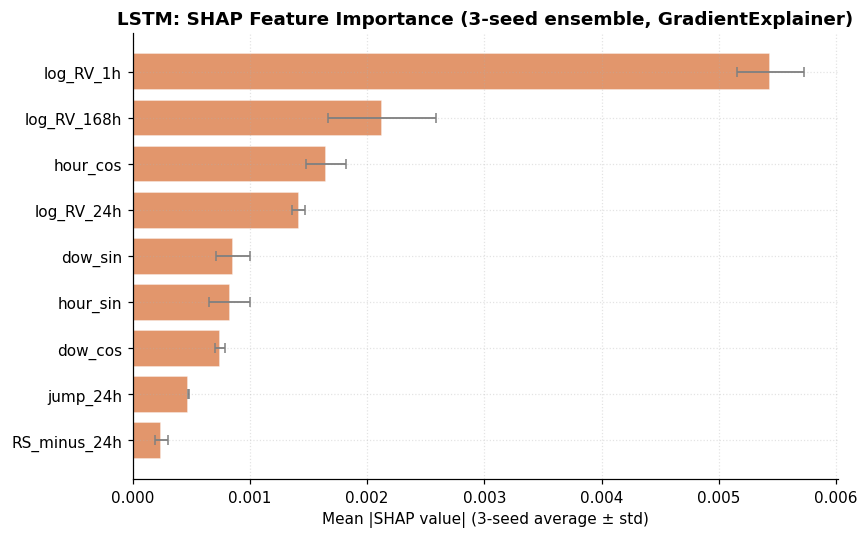

In [89]:
#  LSTM: SHAP Feature Importance
# Mean absolute SHAP value per feature, averaged over the 168-hour lookback
# and 200 randomly sampled test sequences (GradientExplainer).
# Ensemble-averaged: SHAP computed for all 3 seeds and averaged,
# providing a more stable importance estimate than a single representative network.

try:
    import shap

    shap_all_runs = []

    for run in range(LSTM_FINAL_PARAMS["n_runs"]):
        seed = RANDOM_SEED + run
        tf.random.set_seed(seed); np.random.seed(seed)
        print(f"\n  ── SHAP Run {run+1}/{LSTM_FINAL_PARAMS['n_runs']} (seed={seed}) ──")

        shap_m = build_lstm()
        shap_m.fit(X_train_final, y_train_final,
                   validation_data=(X_es, y_es),
                   epochs=LSTM_FINAL_PARAMS["epochs"],
                   batch_size=LSTM_PARAMS["batch_size"],
                   callbacks=[EarlyStopping("val_loss",
                                            patience=LSTM_FINAL_PARAMS["patience"],
                                            restore_best_weights=True, verbose=0)],
                   shuffle=False, verbose=0)

        bg_idx = np.random.choice(len(X_tv),   500, replace=False)
        ex_idx = np.random.choice(len(X_test), 200, replace=False)

        explainer = shap.GradientExplainer(shap_m, X_tv[bg_idx])
        shap_vals = explainer.shap_values(X_test[ex_idx])

        sv = shap_vals[0] if isinstance(shap_vals, list) else shap_vals
        if sv.ndim == 4:
            sv = sv.squeeze(-1)

        run_shap = np.abs(sv).mean(axis=(0, 1))
        shap_all_runs.append(run_shap)
        print(f"  Run {run+1} SHAP done. Top feature: {LSTM_FEATS[np.argmax(run_shap)]}")

        del shap_m
        tf.keras.backend.clear_session()

    # Average across all 3 seeds
    mean_shap = np.mean(shap_all_runs, axis=0)
    std_shap  = np.std(shap_all_runs,  axis=0)

    shap_df = pd.DataFrame({
        "Feature"   : LSTM_FEATS,
        "Mean|SHAP|": mean_shap,
        "Std|SHAP|" : std_shap,
    }).sort_values("Mean|SHAP|", ascending=False)

    print("\n  SHAP Feature Importance (3-seed ensemble average):")
    print(f"  {'Feature':<18} {'Mean|SHAP|':>12} {'Std':>8}")
    print("  " + "─" * 42)
    for _, row in shap_df.iterrows():
        bar = "█" * int(row["Mean|SHAP|"] / mean_shap.max() * 18)
        print(f"  {row['Feature']:<18} {row['Mean|SHAP|']:>10.5f}  "
              f"±{row['Std|SHAP|']:.5f}  {bar}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(shap_df["Feature"], shap_df["Mean|SHAP|"],
            xerr=shap_df["Std|SHAP|"],
            color=MC["LSTM"], alpha=0.85, edgecolor="white",
            error_kw={"elinewidth": 1.2, "capsize": 3, "ecolor": "gray"})
    ax.set_xlabel("Mean |SHAP value| (3-seed average ± std)")
    ax.set_title("LSTM: SHAP Feature Importance (3-seed ensemble, GradientExplainer)",
                 fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

except ImportError:
    print("  shap not installed — run: pip install shap")

log_RV_1h dominates by a wide margin (3.4× the next-largest feature) —
the immediately preceding hour is by far the strongest predictor, echoing
HAR's own coefficient structure (Section 7) where the 1h and 24h lags also carry the most weight. Interestingly, log_RV_168h (weekly) outranks
log_RV_24h (daily) here, suggesting the LSTM is extracting some additional
value from the longer lag that the linear HAR specification does not fully exploit. The calendar features (hour_cos, hour_sin, dow_sin,
dow_cos) collectively rank just below the volatility lags — confirming
that the intraday and weekly seasonality identified in Section 2 (the 13:00 UTC peak, day-of-week effects) is genuinely useful predictive
information, not just descriptive structure. jump_24h and RS_minus_24h rank lowest, consistent with their near-zero correlation with log_RV
(Section 3) and their failure to improve HAR-Extended over HAR-Classic (Section 7).

## 11 — DIEBOLD-MARIANO TEST

In [90]:
def dm_test(e1, e2, h=1):
    """
    DM test with Harvey-Leybourne-Newbold (1997) small-sample correction.

    Tests H0: E[e1^2] = E[e2^2] -- i.e. model 1 and model 2 have equal
    expected squared forecast error. A positive DM stat means model 1's
    errors are larger on average (model 2 is more accurate); negative means
    the opposite. The HLN correction adjusts the standard DM statistic for
    finite-sample bias, which matters here given the moderate sample size
    after WFV/test alignment.

    e1, e2: squared forecast errors for model 1 and model 2.
    Returns: DM statistic, HLN-corrected t-statistic, p-value, interpretation.
    """
    d  = np.asarray(e1, float) - np.asarray(e2, float)
    n  = len(d)
    d_bar = d.mean()
    gamma0 = np.mean((d - d_bar) ** 2)
    gammas = sum(
        2 * np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
        for k in range(1, h)
    ) if h > 1 else 0
    var_d = (gamma0 + gammas) / n
    if var_d <= 0:
        return 0.0, 0.0, 1.0, "indeterminate"
    dm_stat = d_bar / np.sqrt(var_d)
    k_h     = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    t_stat  = dm_stat * k_h
    p_val   = 2 * (1 - t_dist.cdf(abs(t_stat), df=n - 1))
    if p_val < 0.01:   interp = "*** (p<0.01) highly significant"
    elif p_val < 0.05: interp = "**  (p<0.05) significant"
    elif p_val < 0.10: interp = "*   (p<0.10) marginally significant"
    else:              interp = "    (p>=0.10) not significant"
    return float(dm_stat), float(t_stat), float(p_val), interp

- Thıs test formally answers the question every previous
section has only touched on indirectly: *are the differences in forecast
accuracy between models statistically meaningful, or could they arise from
chance?* It compares pairs of models on squared log-error loss, using all
17,372 test-period observations common to every model (the LSTM-aligned
window established in Section 6).

In [91]:
#  Pairwise DM tests across all six models 

# All error series are truncated to the shortest common length (LSTM's 17,372-hour test window, Section 6) before any comparison, ensuring every pairwise test is computed on identical calendar hours.

MODEL_ORDER = ["Random Walk","Historical Mean",
               "HAR-Classic","HAR-Extended","MC-GARCH","LSTM"]

dm_models = [m for m in MODEL_ORDER if m in dm_errors]
min_len = min(len(dm_errors[m]) for m in dm_models)
dm_errs = {m: dm_errors[m][:min_len] for m in dm_models}
dm_rows = []

print(f" Pairwise DM Tests:\n")
print(f" {'Model 1':<18} {'Model 2':<18} {'DM stat':>9} "
      f"{'t-stat':>8} {'p-value':>9}  {'Significance'}")
print("  " + "─" * 80)

for i, m1 in enumerate(dm_models):
    for m2 in dm_models[i+1:]:
        dm_s, t_s, p_v, interp = dm_test(dm_errs[m1], dm_errs[m2])
        dm_rows.append({"Model 1": m1, "Model 2": m2,
                        "DM stat": dm_s, "t-stat": t_s,
                        "p-value": p_v, "Significance": interp})
        print(f"  {m1:<18} {m2:<18} {dm_s:>9.4f} {t_s:>8.4f} "
              f"{p_v:>9.4f}  {interp}")

dm_df = pd.DataFrame(dm_rows)

 Pairwise DM Tests:

 Model 1            Model 2              DM stat   t-stat   p-value  Significance
  ────────────────────────────────────────────────────────────────────────────────
  Random Walk        Historical Mean     -58.7293 -58.7276    0.0000  *** (p<0.01) highly significant
  Random Walk        HAR-Classic          17.1387  17.1382    0.0000  *** (p<0.01) highly significant
  Random Walk        HAR-Extended         16.8078  16.8073    0.0000  *** (p<0.01) highly significant
  Random Walk        MC-GARCH            -19.3343 -19.3337    0.0000  *** (p<0.01) highly significant
  Random Walk        LSTM                  8.6489   8.6487    0.0000  *** (p<0.01) highly significant
  Historical Mean    HAR-Classic          71.1120  71.1099    0.0000  *** (p<0.01) highly significant
  Historical Mean    HAR-Extended         71.5106  71.5085    0.0000  *** (p<0.01) highly significant
  Historical Mean    MC-GARCH             63.0658  63.0640    0.0000  *** (p<0.01) highly significan

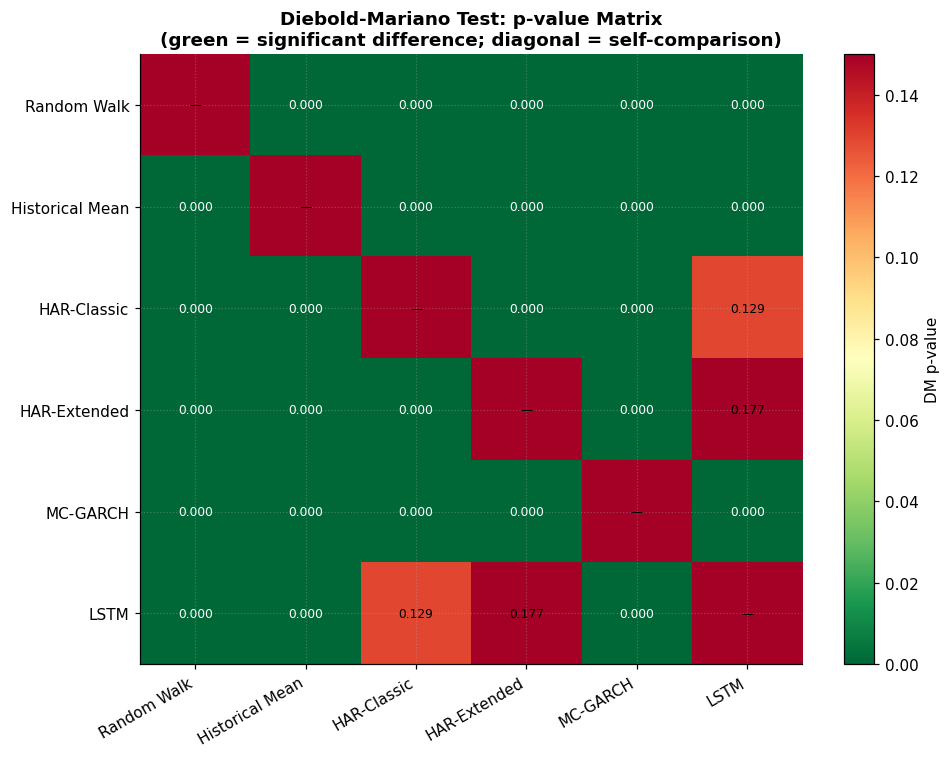

In [92]:
#  DM heatmap 

# p-value matrix across all six models. Lower (greener) values indicate a
# more statistically significant difference in accuracy between the pair.

dm_mat = pd.DataFrame(np.nan, index=dm_models, columns=dm_models)
for _, row in dm_df.iterrows():
    dm_mat.loc[row["Model 1"], row["Model 2"]] = row["p-value"]
    dm_mat.loc[row["Model 2"], row["Model 1"]] = row["p-value"]

fig, ax = plt.subplots(figsize=(9, 7))
vals = dm_mat.values.copy()
vals[np.isnan(vals)] = 1.0
im = ax.imshow(vals, cmap="RdYlGn_r", vmin=0, vmax=0.15, aspect="auto")

plt.colorbar(im, ax=ax, label="DM p-value")
ax.set_xticks(range(len(dm_models)))
ax.set_xticklabels(dm_models, rotation=30, ha="right")
ax.set_yticks(range(len(dm_models)))
ax.set_yticklabels(dm_models)

for i in range(len(dm_models)):
    for j in range(len(dm_models)):
        v = dm_mat.values[i, j]
        txt = f"{v:.3f}" if not np.isnan(v) else "—"
        clr = "white" if (not np.isnan(v) and v < 0.07) else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8, color=clr)
        
ax.set_title("Diebold-Mariano Test: p-value Matrix\n"
             "(green = significant difference; diagonal = self-comparison)",
             fontweight="bold")

plt.tight_layout(); plt.show()

Three groups of results emerge.

- Both naive benchmarks are decisively beaten by every fitted model. Random Walk and Historical Mean are significantly worse than HAR, MC-GARCH and LSTM in every comparison (p<0.01) confirming that all three fitted approaches add genuine forecasting value over trivial baselines.

- HAR-Classic and LSTM are statistically indistinguishable. The two central comparisons of this thesis — HAR-Classic vs LSTM (p=0.130) and HAR-Extended vs LSTM (p=0.177) — both fail to reject the null of equal squared-error accuracy. A 3-parameter linear regression performs no worse, in a statistically rigorous sense, than a 31,393-parameter neural network trained on a GPU. This is the strongest evidence in the thesis for the parsimony argument: added model complexity does not translate into a measurable accuracy gain here.

- MC-GARCH is significantly worse than every other fitted model on squared log-error (p<0.01 against both HAR specifications and LSTM). This appears to contradict MC-GARCH's strong QLIKE performance (Section 8.5, Section 10) — but the two results are not in conflict: DM here tests squared error in log_RV space, while QLIKE is an asymmetric loss computed in RV (level) space. MC-GARCH's systematic log-scale under-prediction (negative MZ intercept, Section 8) is penalised heavily by squared log-error, but happens to translate into RV-scale forecasts that are well-suited to QLIKE's spike-sensitive loss structure. A model can simultaneously be the significantly worst performer under one loss function and the best performer under another — the central tension explored further in Section 12.
HAR-Extended remains significantly worse than HAR-Classic (p=0.0004), reconfirming Section 7's finding that the added jump and semivariance features introduce noise rather than signal in this dataset.